# Project 3 — Dataset 3: IBM HR Employee Attrition

## Kernel and Non-Kernel Learning Under Real-World Data Imperfections

This notebook performs a complete, assignment-aligned analysis for **Dataset 3: IBM HR Employee Attrition**.

The prediction task is:

- **Classification Target:** `Attrition`

The assignment requires more than raw model accuracy. Therefore, this notebook focuses on:

1. Data quality investigation
2. Missing value analysis and missingness reasoning
3. Outlier analysis using Z-score, IQR, and a Simple Isolation Forest implemented from scratch
4. Feature quality analysis
5. Root-driver investigation for employee attrition
6. Feature selection
7. Imbalance handling using undersampling, oversampling, and SMOTE from scratch
8. Non-kernel model implementation from scratch
9. Kernel model implementation from scratch
10. Failure analysis
11. Bias and fairness discussion
12. Computational complexity discussion
13. Report-ready summaries

All core modeling implementations are written using **NumPy/SciPy only**, without scikit-learn.

## 0. Project Setup

This section imports the libraries used throughout the notebook.

We use:

- `pandas` for tabular data handling
- `numpy` for numerical operations and from-scratch algorithms
- `scipy` for statistical tests and linear algebra
- `matplotlib` for visualization

The random seed is fixed to make the experiments reproducible.

In [1]:
# ============================================================
# Section 0: Project Setup
# ============================================================

import os
import time
import math
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import eigh

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 240)

OUTPUT_DIR = Path("outputs_hr_attrition")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")
print(f"Random seed fixed at: {RANDOM_STATE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Libraries imported successfully.
Random seed fixed at: 42
Output directory: C:\Users\Administrator\Desktop\ML Projects\dataset3\outputs_hr_attrition


## 1. Load the IBM HR Employee Attrition Dataset

In this section, we load the raw HR dataset.

The dataset contains employee-level records. The main supervised learning target is `Attrition`, which indicates whether an employee left the company.

Before cleaning or modeling, we inspect:

- Number of rows
- Number of columns
- First records
- Raw column names

In [2]:
# ============================================================
# Section 1: Load the IBM HR Employee Attrition Dataset
# ============================================================

# This loader is intentionally robust because the uploaded file name may contain
# a version suffix such as "(2)". The rest of the notebook uses df_raw, so this
# cell keeps the original structure unchanged while making execution reproducible.

DATA_PATH_CANDIDATES = [
    Path("/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition(2).csv"),
    Path("/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    Path("WA_Fn-UseC_-HR-Employee-Attrition(2).csv"),
    Path("WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    Path("./WA_Fn-UseC_-HR-Employee-Attrition(2).csv"),
    Path("./WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    Path("../WA_Fn-UseC_-HR-Employee-Attrition(2).csv"),
    Path("../WA_Fn-UseC_-HR-Employee-Attrition.csv")
]

DATA_PATH = None

for candidate_path in DATA_PATH_CANDIDATES:
    if candidate_path.exists():
        DATA_PATH = candidate_path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "HR attrition CSV file was not found. Please place the CSV file in the notebook folder "
        "or update DATA_PATH_CANDIDATES."
    )

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset path: {DATA_PATH}")
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

print("\nFirst five rows:")
display(df_raw.head())

print("\nColumn names:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {col}")


Dataset loaded successfully.
Dataset path: WA_Fn-UseC_-HR-Employee-Attrition.csv
Number of rows: 1470
Number of columns: 35

First five rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



Column names:
01. Age
02. Attrition
03. BusinessTravel
04. DailyRate
05. Department
06. DistanceFromHome
07. Education
08. EducationField
09. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager


## 2. Basic Schema and Data Type Inspection

This section summarizes the schema of the dataset.

For each column, we inspect:

- Data type
- Number of missing values
- Missing rate
- Number of unique values
- Example values

This helps identify categorical features, numerical features, constant features, identifiers, and possible target leakage.

In [3]:
# ============================================================
# Section 2: Basic Schema and Data Type Inspection
# ============================================================

df = df_raw.copy()

schema_rows = []
for col in df.columns:
    examples = df[col].dropna().astype(str).unique()[:5]
    schema_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "non_null_count": int(df[col].notna().sum()),
        "missing_count": int(df[col].isna().sum()),
        "missing_rate": float(df[col].isna().mean()),
        "unique_count": int(df[col].nunique(dropna=False)),
        "unique_rate": float(df[col].nunique(dropna=False) / len(df)),
        "example_values": ", ".join(examples)
    })

schema_table = pd.DataFrame(schema_rows).sort_values(
    ["missing_rate", "unique_count"],
    ascending=[False, False]
).reset_index(drop=True)

display(schema_table)
print("\nData type counts:")
display(df.dtypes.astype(str).value_counts())

schema_table.to_csv(OUTPUT_DIR / "hr_schema_table.csv", index=False)

,column,dtype,non_null_count,missing_count,missing_rate,unique_count,unique_rate,example_values
0,EmployeeNumber,int64,1470,0,0.0,1470,1.000000,"1, 2, 4, 5, 7"
1,MonthlyRate,int64,1470,0,0.0,1427,0.970748,"19479, 24907, 2396, 23159, 16632"
2,MonthlyIncome,int64,1470,0,0.0,1349,0.917687,"5993, 5130, 2090, 2909, 3468"
3,DailyRate,int64,1470,0,0.0,886,0.602721,"1102, 279, 1373, 1392, 591"
4,HourlyRate,int64,1470,0,0.0,71,0.048299,"94, 61, 92, 56, 40"
5,Age,int64,1470,0,0.0,43,0.029252,"41, 49, 37, 33, 27"
6,TotalWorkingYears,int64,1470,0,0.0,40,0.027211,"8, 10, 7, 6, 12"
7,YearsAtCompany,int64,1470,0,0.0,37,0.025170,"6, 10, 0, 8, 2"
8,DistanceFromHome,int64,1470,0,0.0,29,0.019728,"1, 8, 2, 3, 24"
9,YearsInCurrentRole,int64,1470,0,0.0,19,0.012925,"4, 7, 0, 2, 5"



Data type counts:


int64     26
object     9
Name: count, dtype: int64

## 3. Target Construction and Label Quality Analysis

The classification target is `Attrition`.

Raw values are usually:

- `Yes`: employee left the company
- `No`: employee stayed

We convert this target into a binary label:

- `1`: Attrition = Yes
- `0`: Attrition = No

Label quality is also investigated because the assignment asks us to document ambiguous ground truths and possible data collection bias.

In this dataset, `Attrition` is a historical HR outcome. It is clear as a binary label, but it may still contain organizational bias because resignation, termination, internal transfer, and voluntary turnover may be collapsed into one binary outcome.

In [4]:
# ============================================================
# Section 3: Target Construction and Label Quality Analysis
# ============================================================

if "Attrition" not in df.columns:
    raise KeyError("Target column 'Attrition' was not found in the dataset.")

def clean_attrition(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value == "yes":
        return 1
    if value == "no":
        return 0
    return np.nan


df["attrition_binary"] = df["Attrition"].apply(clean_attrition)

label_quality_summary = pd.DataFrame({
    "target_column": ["Attrition", "attrition_binary"],
    "missing_count": [df["Attrition"].isna().sum(), df["attrition_binary"].isna().sum()],
    "missing_rate": [df["Attrition"].isna().mean(), df["attrition_binary"].isna().mean()],
    "unique_values": [df["Attrition"].nunique(dropna=False), df["attrition_binary"].nunique(dropna=False)]
})

display(label_quality_summary)

print("Raw Attrition distribution:")
display(df["Attrition"].value_counts(dropna=False))

print("\nBinary attrition distribution:")
display(df["attrition_binary"].value_counts(dropna=False))

print("\nBinary attrition distribution normalized:")
display(df["attrition_binary"].value_counts(normalize=True, dropna=False))

# Report-ready label quality risk table.
# The label is operationally clear, but the underlying HR meaning can still be ambiguous.
label_quality_risk_table = pd.DataFrame({
    "label_quality_issue": [
        "Ambiguous attrition meaning",
        "No reason for leaving",
        "Historical organizational bias",
        "Right-censoring risk",
        "Voluntary vs involuntary attrition not separated"
    ],
    "why_it_matters": [
        "The label only says whether the employee left, not why they left.",
        "The model cannot distinguish salary dissatisfaction, career change, termination, relocation, or retirement.",
        "Past HR decisions may reflect organizational patterns that should not be blindly automated.",
        "Employees labeled as non-attrition may leave after the data snapshot.",
        "Voluntary resignation and company-driven termination may have different causes."
    ],
    "impact_on_model": [
        "The model predicts attrition risk, not causal reasons.",
        "Feature importance should be interpreted carefully.",
        "Fairness and group-level reliability must be checked.",
        "Some negative labels may become positive in the future.",
        "The label combines multiple processes into one binary target."
    ],
    "mitigation_in_this_project": [
        "Use failure analysis and avoid causal claims.",
        "Report root drivers as associations, not causes.",
        "Evaluate performance across demographic and job-related groups.",
        "Discuss temporal limitations in the final report.",
        "State that the target is operational attrition, not a causal resignation label."
    ]
})

print("\nReport-ready label quality risk table:")
display(label_quality_risk_table)

label_quality_summary.to_csv(OUTPUT_DIR / "hr_label_quality_summary.csv", index=False)
label_quality_risk_table.to_csv(OUTPUT_DIR / "hr_label_quality_risk_table.csv", index=False)


,target_column,missing_count,missing_rate,unique_values
0,Attrition,0,0.0,2
1,attrition_binary,0,0.0,2


Raw Attrition distribution:


Attrition
No     1233
Yes     237
Name: count, dtype: int64


Binary attrition distribution:


attrition_binary
0    1233
1     237
Name: count, dtype: int64


Binary attrition distribution normalized:


attrition_binary
0    0.838776
1    0.161224
Name: proportion, dtype: float64


Report-ready label quality risk table:


,label_quality_issue,why_it_matters,impact_on_model,mitigation_in_this_project
0,Ambiguous attrition meaning,"The label only says whether the employee left,...","The model predicts attrition risk, not causal ...",Use failure analysis and avoid causal claims.
1,No reason for leaving,The model cannot distinguish salary dissatisfa...,Feature importance should be interpreted caref...,"Report root drivers as associations, not causes."
2,Historical organizational bias,Past HR decisions may reflect organizational p...,Fairness and group-level reliability must be c...,Evaluate performance across demographic and jo...
3,Right-censoring risk,Employees labeled as non-attrition may leave a...,Some negative labels may become positive in th...,Discuss temporal limitations in the final report.
4,Voluntary vs involuntary attrition not separated,Voluntary resignation and company-driven termi...,The label combines multiple processes into one...,State that the target is operational attrition...


## 4. Class Imbalance Investigation

Employee attrition is usually an imbalanced classification problem.

In this dataset, the minority class is the attrition class (`Yes`). This is important because a model can obtain high accuracy by predicting most employees as non-attrition.

Therefore, accuracy alone is not sufficient.

We will later evaluate models using:

- Precision
- Recall
- F1-score
- Balanced accuracy
- Confusion matrix

We will also implement imbalance handling strategies from scratch:

1. Random undersampling
2. Random oversampling
3. SMOTE-like synthetic oversampling

,class_label,count,rate,class_name
0,0,1233,0.838776,No Attrition
1,1,237,0.161224,Attrition


Majority/minority imbalance ratio: 5.203


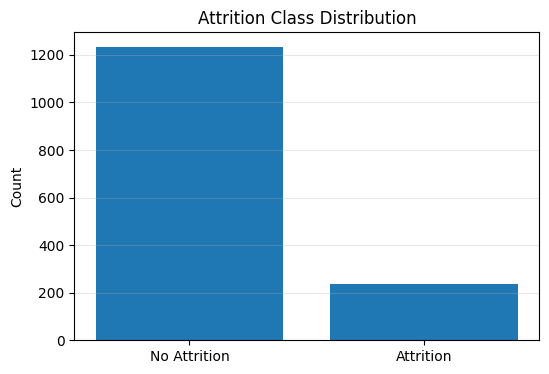

In [5]:
# ============================================================
# Section 4: Class Imbalance Investigation
# ============================================================

class_counts = df["attrition_binary"].value_counts(dropna=False).sort_index()
class_rates = df["attrition_binary"].value_counts(normalize=True, dropna=False).sort_index()

imbalance_table = pd.DataFrame({
    "class_label": class_counts.index,
    "count": class_counts.values,
    "rate": class_rates.values
})

imbalance_table["class_name"] = imbalance_table["class_label"].map({0.0: "No Attrition", 1.0: "Attrition"})

display(imbalance_table)

minority_count = class_counts.min()
majority_count = class_counts.max()
imbalance_ratio = majority_count / minority_count

print(f"Majority/minority imbalance ratio: {imbalance_ratio:.3f}")

plt.figure(figsize=(6, 4))
plt.bar(["No Attrition", "Attrition"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Attrition Class Distribution")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

imbalance_table.to_csv(OUTPUT_DIR / "hr_class_imbalance_table.csv", index=False)

## 5. Missing Data Analysis

The assignment requires missing data analysis and missingness reasoning.

For this dataset, we compute:

- Missing count
- Missing rate
- Missingness group

Then we discuss whether missingness appears MCAR, MAR, or MNAR.

The IBM HR dataset is relatively clean, so it may contain no missing values. This itself is an important data-quality finding: the dataset behaves more like a curated analytics dataset than a messy production HR database.

In [6]:
# ============================================================
# Section 5: Missing Data Analysis
# ============================================================

missing_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_rate": df.isna().mean().values,
    "unique_count": df.nunique(dropna=False).values
})

def missing_group(rate):
    if rate == 0:
        return "No missing"
    elif rate <= 0.05:
        return "Low missingness"
    elif rate <= 0.30:
        return "Moderate missingness"
    elif rate < 1.0:
        return "High missingness"
    else:
        return "Completely missing"

missing_summary["missing_group"] = missing_summary["missing_rate"].apply(missing_group)
missing_summary = missing_summary.sort_values(["missing_rate", "unique_count"], ascending=[False, False]).reset_index(drop=True)

display(missing_summary)

print("Missingness group counts:")
display(missing_summary["missing_group"].value_counts())

missing_summary.to_csv(OUTPUT_DIR / "hr_missing_summary.csv", index=False)

,column,dtype,missing_count,missing_rate,unique_count,missing_group
0,EmployeeNumber,int64,0,0.0,1470,No missing
1,MonthlyRate,int64,0,0.0,1427,No missing
2,MonthlyIncome,int64,0,0.0,1349,No missing
3,DailyRate,int64,0,0.0,886,No missing
4,HourlyRate,int64,0,0.0,71,No missing
5,Age,int64,0,0.0,43,No missing
6,TotalWorkingYears,int64,0,0.0,40,No missing
7,YearsAtCompany,int64,0,0.0,37,No missing
8,DistanceFromHome,int64,0,0.0,29,No missing
9,YearsInCurrentRole,int64,0,0.0,19,No missing


Missingness group counts:


missing_group
No missing    36
Name: count, dtype: int64

## 6. Missingness Mechanism Classification

Even when the dataset has no missing values, the assignment asks for missingness reasoning.

Therefore, we explicitly create a missingness classification table.

If a column has no missing values, the mechanism is marked as `No missing observed`.

If missingness exists, the notebook would classify it using:

- Statistical association evidence
- Domain reasoning
- Feature type

For this HR dataset, the expected result is that most or all columns have no observed missingness.

In [7]:
# ============================================================
# Section 6: Missingness Mechanism Classification
# ============================================================

missingness_classification_rows = []

for _, row in missing_summary.iterrows():
    col = row["column"]
    rate = row["missing_rate"]
    if rate == 0:
        mechanism = "No missing observed"
        evidence = "The column has complete data in this curated dataset."
        imputation = "No imputation required"
    else:
        mechanism = "Unclear / requires association testing"
        evidence = "Missing values exist; check association with observed variables."
        if pd.api.types.is_numeric_dtype(df[col]):
            imputation = "Median imputation + missingness indicator"
        else:
            imputation = "Unknown category + missingness indicator"
    missingness_classification_rows.append({
        "column": col,
        "missing_rate": rate,
        "missingness_mechanism": mechanism,
        "evidence": evidence,
        "planned_imputation": imputation
    })

missingness_classification = pd.DataFrame(missingness_classification_rows)

display(missingness_classification)
missingness_classification.to_csv(OUTPUT_DIR / "hr_missingness_classification.csv", index=False)

,column,missing_rate,missingness_mechanism,evidence,planned_imputation
0,EmployeeNumber,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
1,MonthlyRate,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
2,MonthlyIncome,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
3,DailyRate,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
4,HourlyRate,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
5,Age,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
6,TotalWorkingYears,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
7,YearsAtCompany,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
8,DistanceFromHome,0.0,No missing observed,The column has complete data in this curated d...,No imputation required
9,YearsInCurrentRole,0.0,No missing observed,The column has complete data in this curated d...,No imputation required


## 7. Duplicate and Identifier Analysis

Real-world HR data can include repeated employee records or identifier columns.

In this dataset, `EmployeeNumber` is an identifier-like column. It should not be used as a predictive feature because it can encourage memorization rather than generalization.

We check:

- Full duplicated rows
- Duplicated employee identifiers
- Identifier-like columns

In [8]:
# ============================================================
# Section 7: Duplicate and Identifier Analysis
# ============================================================

full_duplicate_count = int(df.duplicated().sum())
print(f"Fully duplicated rows: {full_duplicate_count}")

identifier_columns = []
for col in df.columns:
    col_lower = col.lower()
    if "number" in col_lower or "id" in col_lower:
        identifier_columns.append(col)

identifier_analysis_rows = []
for col in identifier_columns:
    identifier_analysis_rows.append({
        "column": col,
        "unique_count": df[col].nunique(dropna=False),
        "unique_rate": df[col].nunique(dropna=False) / len(df),
        "duplicated_count": int(df[col].duplicated().sum()),
        "recommendation": "drop_identifier_like" if df[col].nunique(dropna=False) / len(df) > 0.80 else "review_later"
    })

identifier_analysis_table = pd.DataFrame(identifier_analysis_rows)

display(identifier_analysis_table)

identifier_analysis_table.to_csv(OUTPUT_DIR / "hr_identifier_analysis.csv", index=False)

Fully duplicated rows: 0


,column,unique_count,unique_rate,duplicated_count,recommendation
0,EmployeeNumber,1470,1.0,0,drop_identifier_like


## 8. Constant and Near-Constant Feature Analysis

Some HR columns may be constant for all employees.

For example, in the IBM HR dataset, columns such as `EmployeeCount`, `Over18`, and `StandardHours` are often constant.

Constant and near-constant variables contain little useful predictive information and should usually be removed.

In [9]:
# ============================================================
# Section 8: Constant and Near-Constant Feature Analysis
# ============================================================

near_constant_rows = []

for col in df.columns:
    value_counts = df[col].value_counts(dropna=False, normalize=True)
    dominant_value = value_counts.index[0]
    dominant_rate = value_counts.iloc[0]
    unique_count = df[col].nunique(dropna=False)
    
    if unique_count == 1:
        status = "constant"
    elif dominant_rate >= 0.99:
        status = "near_constant"
    else:
        status = "variable"
    
    if status in ["constant", "near_constant"]:
        near_constant_rows.append({
            "column": col,
            "status": status,
            "dominant_value": dominant_value,
            "dominant_rate": dominant_rate,
            "unique_count": unique_count
        })

near_constant_table = pd.DataFrame(near_constant_rows)

display(near_constant_table)
near_constant_table.to_csv(OUTPUT_DIR / "hr_near_constant_features.csv", index=False)

,column,status,dominant_value,dominant_rate,unique_count
0,EmployeeCount,constant,1,1.0,1
1,Over18,constant,Y,1.0,1
2,StandardHours,constant,80,1.0,1


## 9. HR Domain Feature Engineering

The assignment specifically asks us to investigate the root drivers of attrition.

For HR attrition, useful engineered features can describe:

- Career stage
- Income relative to experience
- Tenure pressure
- Promotion stagnation
- Role stability
- Manager stability
- Overtime risk

We create interpretable domain features such as:

- `income_per_total_working_year`
- `years_at_company_ratio`
- `years_without_promotion_ratio`
- `manager_tenure_ratio`
- `role_tenure_ratio`
- `early_career_flag`

These features make the model and the final analysis more meaningful.

In [10]:
# ============================================================
# Section 9: HR Domain Feature Engineering
# ============================================================

EPS = 1e-8

df_fe = df.copy()

# Career and tenure ratios
df_fe["income_per_total_working_year"] = df_fe["MonthlyIncome"] / (df_fe["TotalWorkingYears"] + 1)
df_fe["income_per_job_level"] = df_fe["MonthlyIncome"] / (df_fe["JobLevel"] + EPS)
df_fe["years_at_company_ratio"] = df_fe["YearsAtCompany"] / (df_fe["TotalWorkingYears"] + 1)
df_fe["role_tenure_ratio"] = df_fe["YearsInCurrentRole"] / (df_fe["YearsAtCompany"] + 1)
df_fe["manager_tenure_ratio"] = df_fe["YearsWithCurrManager"] / (df_fe["YearsAtCompany"] + 1)
df_fe["years_without_promotion_ratio"] = df_fe["YearsSinceLastPromotion"] / (df_fe["YearsAtCompany"] + 1)

# Risk flags
df_fe["early_career_flag"] = (df_fe["TotalWorkingYears"] <= 3).astype(int)
df_fe["long_commute_flag"] = (df_fe["DistanceFromHome"] >= df_fe["DistanceFromHome"].quantile(0.75)).astype(int)
df_fe["low_job_satisfaction_flag"] = (df_fe["JobSatisfaction"] <= 2).astype(int)
df_fe["low_environment_satisfaction_flag"] = (df_fe["EnvironmentSatisfaction"] <= 2).astype(int)
df_fe["low_work_life_balance_flag"] = (df_fe["WorkLifeBalance"] <= 2).astype(int)

if "OverTime" in df_fe.columns:
    df_fe["overtime_binary"] = (df_fe["OverTime"].astype(str).str.lower() == "yes").astype(int)

engineered_feature_columns = [
    "income_per_total_working_year",
    "income_per_job_level",
    "years_at_company_ratio",
    "role_tenure_ratio",
    "manager_tenure_ratio",
    "years_without_promotion_ratio",
    "early_career_flag",
    "long_commute_flag",
    "low_job_satisfaction_flag",
    "low_environment_satisfaction_flag",
    "low_work_life_balance_flag",
]

if "overtime_binary" in df_fe.columns:
    engineered_feature_columns.append("overtime_binary")

print("Engineered HR features:")
for col in engineered_feature_columns:
    print("-", col)

display(df_fe[engineered_feature_columns].head())

df_fe[engineered_feature_columns].describe().T.to_csv(OUTPUT_DIR / "hr_engineered_feature_summary.csv")

Engineered HR features:
- income_per_total_working_year
- income_per_job_level
- years_at_company_ratio
- role_tenure_ratio
- manager_tenure_ratio
- years_without_promotion_ratio
- early_career_flag
- long_commute_flag
- low_job_satisfaction_flag
- low_environment_satisfaction_flag
- low_work_life_balance_flag
- overtime_binary


,income_per_total_working_year,income_per_job_level,years_at_company_ratio,role_tenure_ratio,manager_tenure_ratio,years_without_promotion_ratio,early_career_flag,long_commute_flag,low_job_satisfaction_flag,low_environment_satisfaction_flag,low_work_life_balance_flag,overtime_binary
0,665.888889,2996.499985,0.666667,0.571429,0.714286,0.000000,0,0,0,1,1,1
1,466.363636,2564.999987,0.909091,0.636364,0.636364,0.090909,0,0,1,0,0,0
2,261.250000,2089.999979,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,1
3,323.222222,2908.999971,0.888889,0.777778,0.000000,0.333333,0,0,0,0,0,1
4,495.428571,3467.999965,0.285714,0.666667,0.666667,0.666667,0,0,1,1,0,0


## 10. Outlier Analysis Overview

The assignment asks us to compare:

1. Z-score
2. IQR
3. Isolation Forest

For HR attrition, outliers may appear in:

- Monthly income
- Years at company
- Total working years
- Distance from home
- Salary rate variables

Not all outliers are errors. A senior employee with high monthly income is rare but valid.

Therefore, we detect and document outliers instead of blindly deleting them.

In [11]:
# ============================================================
# Section 10: Numeric Distribution Profile for Outlier Analysis
# ============================================================

numeric_columns = [
    col for col in df_fe.columns
    if pd.api.types.is_numeric_dtype(df_fe[col]) and col != "attrition_binary"
]

outlier_profile_rows = []
for col in numeric_columns:
    x = df_fe[col].dropna()
    if len(x) == 0:
        continue
    outlier_profile_rows.append({
        "column": col,
        "mean": x.mean(),
        "median": x.median(),
        "std": x.std(),
        "min": x.min(),
        "p01": x.quantile(0.01),
        "p05": x.quantile(0.05),
        "p25": x.quantile(0.25),
        "p75": x.quantile(0.75),
        "p95": x.quantile(0.95),
        "p99": x.quantile(0.99),
        "max": x.max(),
        "skewness": x.skew()
    })

outlier_profile_table = pd.DataFrame(outlier_profile_rows).sort_values("skewness", ascending=False).reset_index(drop=True)

display(outlier_profile_table)
outlier_profile_table.to_csv(OUTPUT_DIR / "hr_outlier_numeric_profile.csv", index=False)

,column,mean,median,std,min,p01,p05,p25,p75,p95,p99,max,skewness
0,early_career_flag,0.112245,0.000000,0.315775,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.459241
1,YearsSinceLastPromotion,2.187755,1.000000,3.222430,0.000000,0.000000,0.000000,0.000000,3.000000,9.000000,14.000000,15.000000,1.984290
2,PerformanceRating,3.153741,3.000000,0.360824,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,1.921883
3,YearsAtCompany,7.008163,5.000000,6.126525,0.000000,0.000000,1.000000,3.000000,9.000000,20.000000,31.000000,40.000000,1.764529
4,MonthlyIncome,6502.931293,4919.000000,4707.956783,1009.000000,1382.460000,2097.900000,2911.000000,8379.000000,17821.350000,19626.310000,19999.000000,1.369817
5,long_commute_flag,0.255782,0.000000,0.436449,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.120638
6,TotalWorkingYears,11.279592,10.000000,7.780782,0.000000,1.000000,1.000000,6.000000,15.000000,28.000000,35.000000,40.000000,1.117172
7,income_per_total_working_year,587.575385,549.220648,284.650784,95.285714,140.744524,217.165238,374.232143,738.303846,1159.275000,1468.669545,1904.000000,1.051231
8,NumCompaniesWorked,2.693197,2.000000,2.498009,0.000000,0.000000,0.000000,1.000000,4.000000,8.000000,9.000000,9.000000,1.026471
9,JobLevel,2.063946,2.000000,1.106940,1.000000,1.000000,1.000000,1.000000,3.000000,4.000000,5.000000,5.000000,1.025401


**توضیح کوتاه:** توزیع ستون‌های عددی بررسی شد. skewness زیاد یعنی ستون right-skewed است و Z-score ممکن است برای آن کافی نباشد.

## 11. Visualize Important Numeric Distributions

We visualize important HR variables to understand their distributions before outlier detection.

This is useful for deciding whether a variable is skewed and whether robust methods are needed.

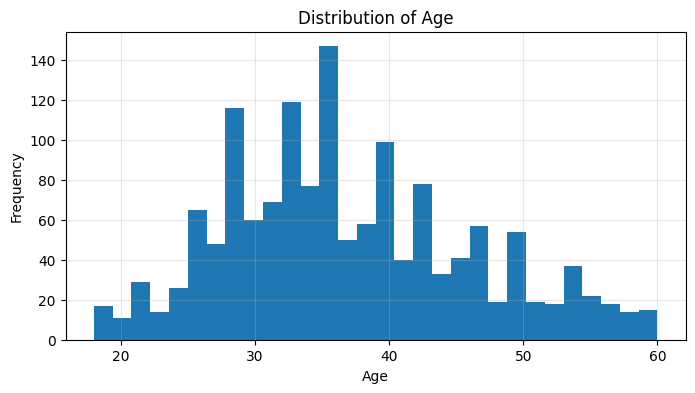

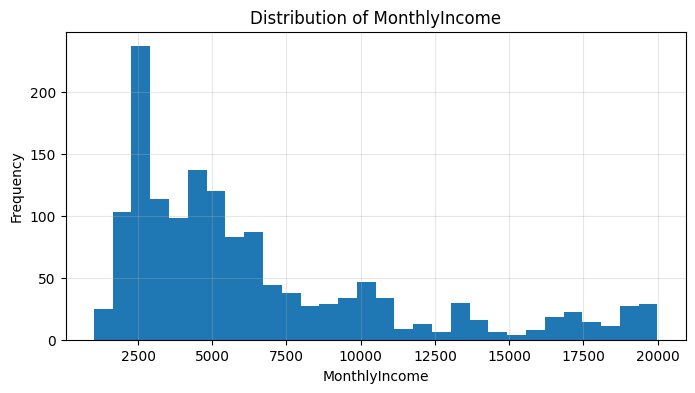

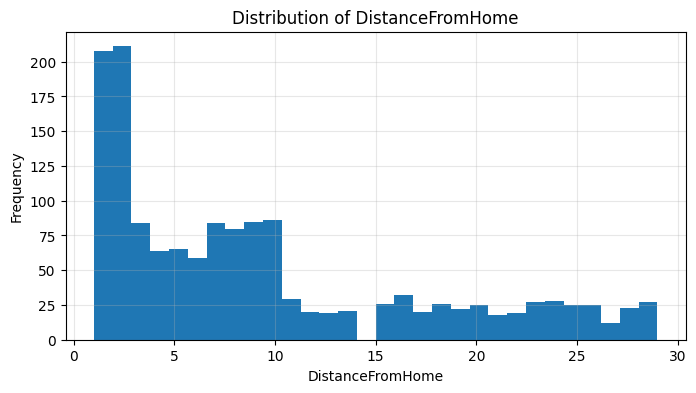

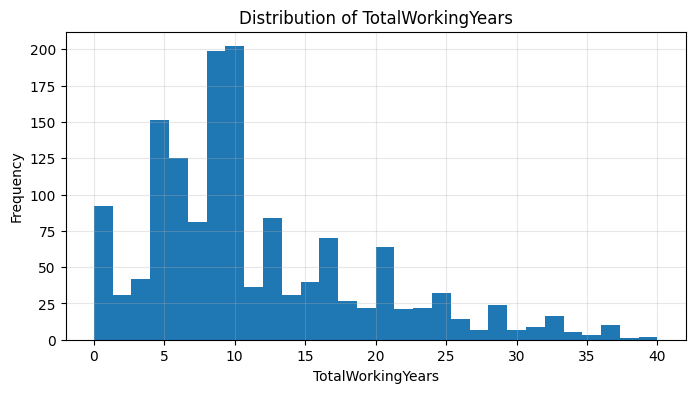

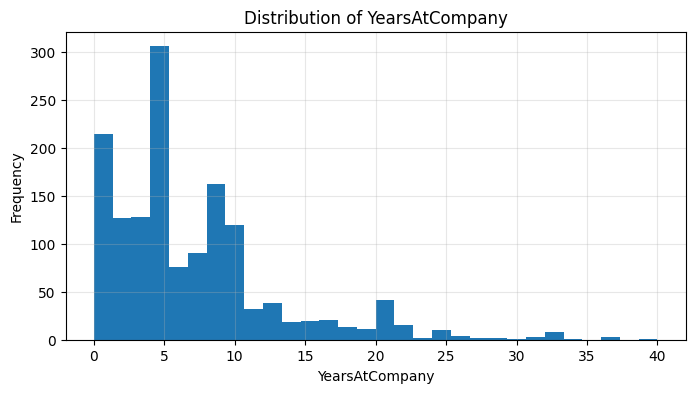

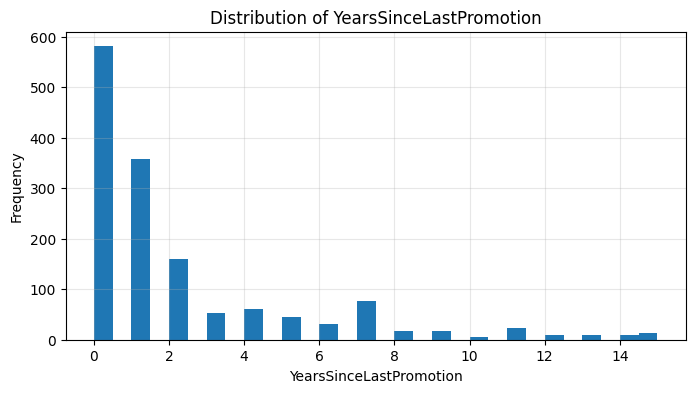

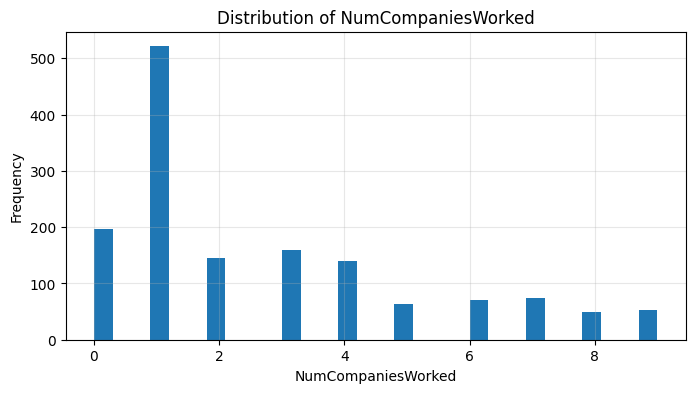

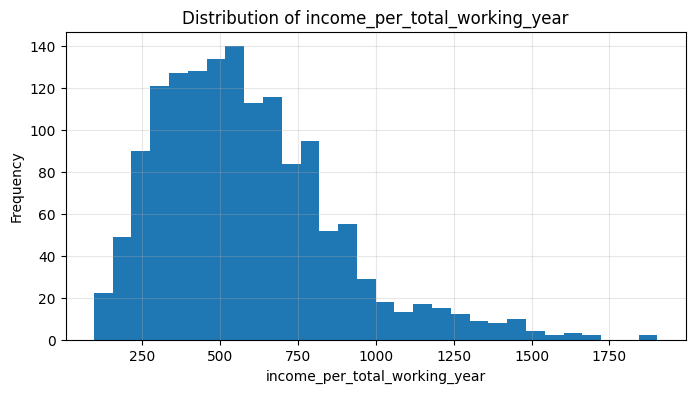

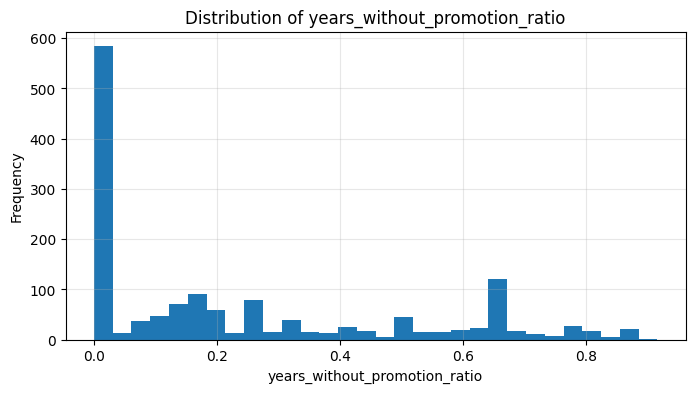

In [12]:
# ============================================================
# Section 11: Visualize Important Numeric Distributions
# ============================================================

important_numeric_plots = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
    "NumCompaniesWorked",
    "income_per_total_working_year",
    "years_without_promotion_ratio"
]

important_numeric_plots = [col for col in important_numeric_plots if col in df_fe.columns]

for col in important_numeric_plots:
    x = df_fe[col].dropna()
    plt.figure(figsize=(8, 4))
    plt.hist(x, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

## 12. Z-score Outlier Detection

The Z-score method flags values far from the mean.

A common threshold is:

`|z| > 3`

This method is simple but sensitive to skewness and extreme values.

In [13]:
# ============================================================
# Section 12: Z-score Outlier Detection
# ============================================================

def detect_zscore_outliers(data, columns, threshold=3.0):
    flags = pd.DataFrame(index=data.index)
    summary_rows = []
    for col in columns:
        x = pd.to_numeric(data[col], errors="coerce")
        mean_value = x.mean(skipna=True)
        std_value = x.std(skipna=True)
        if pd.isna(std_value) or std_value == 0:
            flags[f"z_outlier__{col}"] = False
            continue
        z_scores = ((x - mean_value) / std_value).abs()
        col_flag = (z_scores > threshold).fillna(False)
        flags[f"z_outlier__{col}"] = col_flag
        summary_rows.append({
            "column": col,
            "method": "Z-score",
            "threshold": threshold,
            "mean": mean_value,
            "std": std_value,
            "outlier_count": int(col_flag.sum()),
            "outlier_rate": float(col_flag.mean())
        })
    flags["zscore_outlier_any"] = flags.any(axis=1)
    return flags, pd.DataFrame(summary_rows)

zscore_flags, zscore_summary = detect_zscore_outliers(df_fe, numeric_columns, threshold=3.0)
zscore_summary = zscore_summary.sort_values("outlier_rate", ascending=False).reset_index(drop=True)

display(zscore_summary)
print("Rows flagged by Z-score in at least one numeric variable:", int(zscore_flags["zscore_outlier_any"].sum()))
zscore_summary.to_csv(OUTPUT_DIR / "hr_zscore_outlier_summary.csv", index=False)

,column,method,threshold,mean,std,outlier_count,outlier_rate
0,YearsSinceLastPromotion,Z-score,3.0,2.187755,3.222430,42,0.028571
1,YearsAtCompany,Z-score,3.0,7.008163,6.126525,25,0.017007
2,income_per_total_working_year,Z-score,3.0,587.575385,284.650784,18,0.012245
3,TotalWorkingYears,Z-score,3.0,11.279592,7.780782,16,0.010884
4,YearsWithCurrManager,Z-score,3.0,4.123129,3.568136,14,0.009524
5,YearsInCurrentRole,Z-score,3.0,4.229252,3.623137,13,0.008844
6,DailyRate,Z-score,3.0,802.485714,403.509100,0,0.000000
7,Age,Z-score,3.0,36.923810,9.135373,0,0.000000
8,Education,Z-score,3.0,2.912925,1.024165,0,0.000000
9,DistanceFromHome,Z-score,3.0,9.192517,8.106864,0,0.000000


Rows flagged by Z-score in at least one numeric variable: 101


## 13. IQR Outlier Detection

The IQR method is more robust than Z-score because it uses quartiles.

The rule is:

- Lower bound = `Q1 - 1.5 * IQR`
- Upper bound = `Q3 + 1.5 * IQR`

This is often better for HR variables with skewed distributions.

In [14]:
# ============================================================
# Section 13: IQR Outlier Detection
# ============================================================

def detect_iqr_outliers(data, columns, multiplier=1.5):
    flags = pd.DataFrame(index=data.index)
    summary_rows = []
    for col in columns:
        x = pd.to_numeric(data[col], errors="coerce")
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            flags[f"iqr_outlier__{col}"] = False
            continue
        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr
        col_flag = ((x < lower_bound) | (x > upper_bound)).fillna(False)
        flags[f"iqr_outlier__{col}"] = col_flag
        summary_rows.append({
            "column": col,
            "method": "IQR",
            "multiplier": multiplier,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(col_flag.sum()),
            "outlier_rate": float(col_flag.mean())
        })
    flags["iqr_outlier_any"] = flags.any(axis=1)
    return flags, pd.DataFrame(summary_rows)

iqr_flags, iqr_summary = detect_iqr_outliers(df_fe, numeric_columns, multiplier=1.5)
iqr_summary = iqr_summary.sort_values("outlier_rate", ascending=False).reset_index(drop=True)

display(iqr_summary)
print("Rows flagged by IQR in at least one numeric variable:", int(iqr_flags["iqr_outlier_any"].sum()))
iqr_summary.to_csv(OUTPUT_DIR / "hr_iqr_outlier_summary.csv", index=False)

,column,method,multiplier,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
0,TrainingTimesLastYear,IQR,1.5,2.000000,3.000000,1.000000,0.500000,4.500000,238,0.161905
1,MonthlyIncome,IQR,1.5,2911.000000,8379.000000,5468.000000,-5291.000000,16581.000000,114,0.077551
2,YearsSinceLastPromotion,IQR,1.5,0.000000,3.000000,3.000000,-4.500000,7.500000,107,0.072789
3,YearsAtCompany,IQR,1.5,3.000000,9.000000,6.000000,-6.000000,18.000000,104,0.070748
4,StockOptionLevel,IQR,1.5,0.000000,1.000000,1.000000,-1.500000,2.500000,85,0.057823
5,TotalWorkingYears,IQR,1.5,6.000000,15.000000,9.000000,-7.500000,28.500000,63,0.042857
6,NumCompaniesWorked,IQR,1.5,1.000000,4.000000,3.000000,-3.500000,8.500000,52,0.035374
7,income_per_total_working_year,IQR,1.5,374.232143,738.303846,364.071703,-171.875412,1284.411401,43,0.029252
8,YearsInCurrentRole,IQR,1.5,2.000000,7.000000,5.000000,-5.500000,14.500000,21,0.014286
9,YearsWithCurrManager,IQR,1.5,2.000000,7.000000,5.000000,-5.500000,14.500000,14,0.009524


Rows flagged by IQR in at least one numeric variable: 572


## 14. Simple Isolation Forest from Scratch

Z-score and IQR are univariate methods.

Isolation Forest is multivariate. It detects observations that are easy to isolate using random splits.

We implement a simplified Isolation Forest from scratch using NumPy.

No scikit-learn is used.

In [15]:
# ============================================================
# Section 14: Simple Isolation Forest from Scratch
# ============================================================

def average_path_length(n):
    n = np.asarray(n, dtype=float)
    result = np.zeros_like(n, dtype=float)
    mask_gt_2 = n > 2
    mask_eq_2 = n == 2
    result[mask_eq_2] = 1.0
    result[mask_gt_2] = 2.0 * (np.log(n[mask_gt_2] - 1.0) + 0.5772156649) - (2.0 * (n[mask_gt_2] - 1.0) / n[mask_gt_2])
    return result

class IsolationTreeNode:
    def __init__(self, size, depth, feature_index=None, split_value=None, left=None, right=None):
        self.size = size
        self.depth = depth
        self.feature_index = feature_index
        self.split_value = split_value
        self.left = left
        self.right = right
    @property
    def is_external(self):
        return self.left is None and self.right is None

class IsolationTree:
    def __init__(self, max_depth, random_state=None):
        self.max_depth = max_depth
        self.rng = np.random.default_rng(random_state)
        self.root = None
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.root = self._build_tree(X, depth=0)
        return self
    def _build_tree(self, X, depth):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples <= 1:
            return IsolationTreeNode(size=n_samples, depth=depth)
        feature_mins = np.nanmin(X, axis=0)
        feature_maxs = np.nanmax(X, axis=0)
        valid_features = np.where(feature_maxs > feature_mins)[0]
        if len(valid_features) == 0:
            return IsolationTreeNode(size=n_samples, depth=depth)
        feature_index = int(self.rng.choice(valid_features))
        split_value = float(self.rng.uniform(feature_mins[feature_index], feature_maxs[feature_index]))
        left_mask = X[:, feature_index] < split_value
        right_mask = ~left_mask
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return IsolationTreeNode(size=n_samples, depth=depth)
        left_child = self._build_tree(X[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], depth + 1)
        return IsolationTreeNode(n_samples, depth, feature_index, split_value, left_child, right_child)
    def path_length_one(self, x, node=None, depth=0):
        if node is None:
            node = self.root
        if node.is_external:
            return depth + float(average_path_length(np.array([node.size]))[0])
        if x[node.feature_index] < node.split_value:
            return self.path_length_one(x, node.left, depth + 1)
        return self.path_length_one(x, node.right, depth + 1)
    def path_length(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self.path_length_one(row) for row in X], dtype=float)

class SimpleIsolationForest:
    def __init__(self, n_trees=100, sample_size=256, max_depth=None, random_state=42):
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.max_depth = max_depth
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []
        self.actual_sample_size_ = None
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        self.actual_sample_size_ = min(self.sample_size, n_samples)
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(self.actual_sample_size_)))
        self.trees = []
        for _ in range(self.n_trees):
            sample_indices = self.rng.choice(n_samples, size=self.actual_sample_size_, replace=False)
            tree = IsolationTree(self.max_depth, random_state=self.rng.integers(0, 10**9))
            tree.fit(X[sample_indices])
            self.trees.append(tree)
        return self
    def path_length(self, X):
        X = np.asarray(X, dtype=float)
        all_lengths = np.zeros((X.shape[0], len(self.trees)), dtype=float)
        for j, tree in enumerate(self.trees):
            all_lengths[:, j] = tree.path_length(X)
        return all_lengths.mean(axis=1)
    def anomaly_score(self, X):
        avg_lengths = self.path_length(X)
        c_n = float(average_path_length(np.array([self.actual_sample_size_]))[0])
        if c_n == 0:
            return np.ones_like(avg_lengths)
        return 2.0 ** (-avg_lengths / c_n)
    def predict(self, X, contamination=0.05):
        scores = self.anomaly_score(X)
        threshold = np.quantile(scores, 1.0 - contamination)
        labels = (scores >= threshold).astype(int)
        return labels, scores, threshold

print("Simple Isolation Forest implemented successfully.")

Simple Isolation Forest implemented successfully.


## 15. Run Simple Isolation Forest on HR Numeric Features

Before running Isolation Forest, numerical features are median-imputed and robustly scaled.

This prevents variables with large scales, such as `MonthlyIncome`, from dominating random splits.

In [16]:
# ============================================================
# Section 15: Run Simple Isolation Forest on HR Numeric Features
# ============================================================

def prepare_numeric_matrix_for_anomaly(data, columns, clip_value=10.0):
    X_df = data[columns].copy()
    transform_rows = []
    for col in columns:
        x = pd.to_numeric(X_df[col], errors="coerce")
        median_value = x.median()
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(median_value):
            median_value = 0.0
        if pd.isna(iqr) or iqr == 0:
            iqr = 1.0
        X_df[col] = ((x.fillna(median_value) - median_value) / iqr).clip(-clip_value, clip_value)
        transform_rows.append({"column": col, "median": median_value, "iqr": iqr})
    return X_df.values.astype(float), pd.DataFrame(transform_rows)

X_iso, isolation_transform_table = prepare_numeric_matrix_for_anomaly(df_fe, numeric_columns)

start_time = time.time()
iforest = SimpleIsolationForest(n_trees=100, sample_size=256, random_state=RANDOM_STATE)
iforest.fit(X_iso)
iforest_labels, iforest_scores, iforest_threshold = iforest.predict(X_iso, contamination=0.05)
iforest_runtime = time.time() - start_time

df_fe["simple_iforest_score"] = iforest_scores
df_fe["simple_iforest_outlier"] = iforest_labels

print(f"Isolation Forest runtime: {iforest_runtime:.4f} seconds")
print(f"Threshold: {iforest_threshold:.6f}")
print(f"Outlier count: {int(df_fe['simple_iforest_outlier'].sum())}")
print(f"Outlier rate: {df_fe['simple_iforest_outlier'].mean():.4f}")

display(df_fe[["simple_iforest_score", "simple_iforest_outlier"]].sort_values("simple_iforest_score", ascending=False).head(20))

isolation_transform_table.to_csv(OUTPUT_DIR / "hr_isolation_transform_table.csv", index=False)

Isolation Forest runtime: 4.9396 seconds
Threshold: 0.553543
Outlier count: 74
Outlier rate: 0.0503


,simple_iforest_score,simple_iforest_outlier
976,0.604208,1
1301,0.600756,1
875,0.597167,1
126,0.592465,1
427,0.590738,1
918,0.588495,1
914,0.587335,1
1116,0.587085,1
1078,0.586828,1
656,0.585092,1


## 16. Compare Z-score, IQR, and Isolation Forest

We compare the three outlier methods.

Rows flagged by several methods are more suspicious than rows flagged by only one method.

In [17]:
# ============================================================
# Section 16: Compare Z-score, IQR, and Isolation Forest
# ============================================================

outlier_comparison = pd.DataFrame(index=df_fe.index)
outlier_comparison["zscore_outlier"] = zscore_flags["zscore_outlier_any"].astype(int)
outlier_comparison["iqr_outlier"] = iqr_flags["iqr_outlier_any"].astype(int)
outlier_comparison["simple_iforest_outlier"] = df_fe["simple_iforest_outlier"].astype(int)
outlier_comparison["number_of_methods_flagged"] = outlier_comparison.sum(axis=1)

method_summary = pd.DataFrame({
    "method": ["Z-score", "IQR", "Simple Isolation Forest"],
    "outlier_count": [
        outlier_comparison["zscore_outlier"].sum(),
        outlier_comparison["iqr_outlier"].sum(),
        outlier_comparison["simple_iforest_outlier"].sum()
    ],
    "outlier_rate": [
        outlier_comparison["zscore_outlier"].mean(),
        outlier_comparison["iqr_outlier"].mean(),
        outlier_comparison["simple_iforest_outlier"].mean()
    ]
})

display(method_summary)
print("Number of methods flagging each row:")
display(outlier_comparison["number_of_methods_flagged"].value_counts().sort_index())

# Preserve indicators in df_fe
df_fe["zscore_outlier_any"] = outlier_comparison["zscore_outlier"]
df_fe["iqr_outlier_any"] = outlier_comparison["iqr_outlier"]
df_fe["number_of_outlier_methods_flagged"] = outlier_comparison["number_of_methods_flagged"]
df_fe["high_confidence_outlier"] = (
    (df_fe["simple_iforest_outlier"] == 1) &
    ((df_fe["zscore_outlier_any"] == 1) | (df_fe["iqr_outlier_any"] == 1))
).astype(int)

method_summary.to_csv(OUTPUT_DIR / "hr_outlier_method_summary.csv", index=False)
df_fe.to_csv(OUTPUT_DIR / "hr_feature_engineered_outlier_treated.csv", index=False)

,method,outlier_count,outlier_rate
0,Z-score,101,0.068707
1,IQR,572,0.389116
2,Simple Isolation Forest,74,0.050340


Number of methods flagging each row:


number_of_methods_flagged
0    889
1    456
2     84
3     41
Name: count, dtype: int64

## 17. Root Driver Analysis: Numerical Features

The assignment asks us to investigate the root drivers of attrition.

For numerical variables, we compare employees who left and employees who stayed.

We compute:

- Mean in each group
- Median in each group
- Standardized mean difference
- Mann-Whitney U p-value
- Absolute effect size ranking

This identifies numerical variables most associated with attrition.

In [18]:
# ============================================================
# Section 17: Root Driver Analysis for Numerical Features
# ============================================================

root_driver_numeric_rows = []

y = df_fe["attrition_binary"]

for col in numeric_columns + engineered_feature_columns + ["simple_iforest_score", "high_confidence_outlier"]:
    if col not in df_fe.columns or col == "attrition_binary":
        continue
    temp = df_fe[[col, "attrition_binary"]].dropna()
    if temp["attrition_binary"].nunique() < 2:
        continue
    group_no = temp.loc[temp["attrition_binary"] == 0, col]
    group_yes = temp.loc[temp["attrition_binary"] == 1, col]
    if len(group_no) < 5 or len(group_yes) < 5:
        continue
    pooled_std = temp[col].std()
    standardized_mean_diff = np.nan if pooled_std == 0 else (group_yes.mean() - group_no.mean()) / pooled_std
    try:
        _, p_value = stats.mannwhitneyu(group_yes, group_no, alternative="two-sided")
    except Exception:
        p_value = np.nan
    root_driver_numeric_rows.append({
        "feature": col,
        "mean_no_attrition": group_no.mean(),
        "mean_attrition": group_yes.mean(),
        "median_no_attrition": group_no.median(),
        "median_attrition": group_yes.median(),
        "standardized_mean_difference_yes_minus_no": standardized_mean_diff,
        "abs_effect_size": abs(standardized_mean_diff) if pd.notna(standardized_mean_diff) else np.nan,
        "mann_whitney_p_value": p_value
    })

numeric_root_driver_table = pd.DataFrame(root_driver_numeric_rows).sort_values("abs_effect_size", ascending=False).reset_index(drop=True)

display(numeric_root_driver_table.head(30))
numeric_root_driver_table.to_csv(OUTPUT_DIR / "hr_numeric_root_driver_analysis.csv", index=False)

,feature,mean_no_attrition,mean_attrition,median_no_attrition,median_attrition,standardized_mean_difference_yes_minus_no,abs_effect_size,mann_whitney_p_value
0,overtime_binary,0.234388,0.535865,0.000000,1.000000,0.669048,0.669048,3.985654e-21
1,overtime_binary,0.234388,0.535865,0.000000,1.000000,0.669048,0.669048,3.985654e-21
2,early_career_flag,0.082725,0.265823,0.000000,0.000000,0.579836,0.579836,2.955681e-16
3,early_career_flag,0.082725,0.265823,0.000000,0.000000,0.579836,0.579836,2.955681e-16
4,simple_iforest_score,0.491936,0.508753,0.489727,0.508552,0.505430,0.505430,7.178748e-13
5,TotalWorkingYears,11.862936,8.244726,10.000000,7.000000,-0.465019,0.465019,2.399569e-14
6,JobLevel,2.145985,1.637131,2.000000,1.000000,-0.459695,0.459695,2.956987e-13
7,YearsInCurrentRole,4.484185,2.902954,3.000000,2.000000,-0.436426,0.436426,4.429560e-12
8,MonthlyIncome,6832.739659,4787.092827,5204.000000,3202.000000,-0.434508,0.434508,2.950831e-14
9,Age,37.561233,33.607595,36.000000,32.000000,-0.432783,0.432783,5.304342e-11


## 18. Root Driver Analysis: Categorical Features

For categorical variables, we test whether category distribution is associated with attrition.

We compute:

- Chi-square test of independence
- Cramér's V association strength
- Attrition rate by category

This helps identify categorical drivers such as:

- OverTime
- JobRole
- MaritalStatus
- Department
- BusinessTravel

In [19]:
# ============================================================
# Section 18: Root Driver Analysis for Categorical Features
# ============================================================

categorical_columns = [col for col in df_fe.columns if df_fe[col].dtype == "object" and col != "Attrition"]

def cramers_v_from_contingency(contingency):
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.values.sum()
    if n == 0:
        return np.nan, p
    r, k = contingency.shape
    phi2 = chi2 / n
    denom = min(k - 1, r - 1)
    if denom == 0:
        return np.nan, p
    return math.sqrt(phi2 / denom), p

categorical_driver_rows = []
category_rate_tables = []

for col in categorical_columns:
    temp = df_fe[[col, "attrition_binary"]].dropna().copy()
    if temp[col].nunique() < 2:
        continue
    contingency = pd.crosstab(temp[col], temp["attrition_binary"])
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue
    cv, p_value = cramers_v_from_contingency(contingency)
    attrition_rate_by_cat = temp.groupby(col)["attrition_binary"].mean().sort_values(ascending=False)
    categorical_driver_rows.append({
        "feature": col,
        "unique_categories": temp[col].nunique(),
        "cramers_v": cv,
        "chi_square_p_value": p_value,
        "highest_attrition_category": attrition_rate_by_cat.index[0],
        "highest_attrition_rate": attrition_rate_by_cat.iloc[0],
        "lowest_attrition_category": attrition_rate_by_cat.index[-1],
        "lowest_attrition_rate": attrition_rate_by_cat.iloc[-1]
    })
    rate_df = attrition_rate_by_cat.reset_index()
    rate_df.columns = ["category", "attrition_rate"]
    rate_df["feature"] = col
    category_rate_tables.append(rate_df)

categorical_root_driver_table = pd.DataFrame(categorical_driver_rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
category_attrition_rates = pd.concat(category_rate_tables, ignore_index=True) if category_rate_tables else pd.DataFrame()

display(categorical_root_driver_table)
print("\nCategory-level attrition rates preview:")
display(category_attrition_rates.head(50))

categorical_root_driver_table.to_csv(OUTPUT_DIR / "hr_categorical_root_driver_analysis.csv", index=False)
category_attrition_rates.to_csv(OUTPUT_DIR / "hr_category_attrition_rates.csv", index=False)

,feature,unique_categories,cramers_v,chi_square_p_value,highest_attrition_category,highest_attrition_rate,lowest_attrition_category,lowest_attrition_rate
0,OverTime,2,0.244065,8.158424e-21,Yes,0.305288,No,0.104364
1,JobRole,9,0.242142,2.752482e-15,Sales Representative,0.397590,Research Director,0.025000
2,MaritalStatus,3,0.177211,9.455511e-11,Single,0.255319,Divorced,0.100917
3,BusinessTravel,3,0.128260,5.608614e-06,Travel_Frequently,0.249097,Non-Travel,0.080000
4,EducationField,6,0.104409,6.773980e-03,Human Resources,0.259259,Other,0.134146
5,Department,3,0.085698,4.525607e-03,Sales,0.206278,Research & Development,0.138398
6,Gender,2,0.027565,2.905724e-01,Male,0.170068,Female,0.147959



Category-level attrition rates preview:


,category,attrition_rate,feature
0,Travel_Frequently,0.249097,BusinessTravel
1,Travel_Rarely,0.149569,BusinessTravel
2,Non-Travel,0.080000,BusinessTravel
3,Sales,0.206278,Department
4,Human Resources,0.190476,Department
5,Research & Development,0.138398,Department
6,Human Resources,0.259259,EducationField
7,Technical Degree,0.242424,EducationField
8,Marketing,0.220126,EducationField
9,Life Sciences,0.146865,EducationField


## 19. Feature Quality Analysis

Feature quality analysis identifies features that should not directly enter the model.

We check:

- Direct target leakage
- Identifier columns
- Constant or near-constant columns
- Redundant numerical features
- High-cardinality categorical variables

This creates a transparent feature selection table for the final report.

In [20]:
# ============================================================
# Section 19: Feature Quality Analysis
# ============================================================

# Spearman correlation for numeric redundancy
numeric_for_corr = [col for col in df_fe.columns if pd.api.types.is_numeric_dtype(df_fe[col]) and df_fe[col].nunique(dropna=True) > 1]
corr_matrix = df_fe[numeric_for_corr].corr(method="spearman").abs()

redundant_pairs = []
for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if j <= i:
            continue
        corr_value = corr_matrix.loc[col1, col2]
        if pd.notna(corr_value) and corr_value >= 0.90:
            redundant_pairs.append({"feature_1": col1, "feature_2": col2, "abs_spearman_corr": corr_value})

redundant_pairs_table = pd.DataFrame(redundant_pairs).sort_values("abs_spearman_corr", ascending=False).reset_index(drop=True) if redundant_pairs else pd.DataFrame(columns=["feature_1", "feature_2", "abs_spearman_corr"])

display(redundant_pairs_table.head(50))
redundant_pairs_table.to_csv(OUTPUT_DIR / "hr_redundant_numeric_pairs.csv", index=False)

# High cardinality categorical
high_cardinality_rows = []
for col in categorical_columns:
    unique_count = df_fe[col].nunique(dropna=False)
    unique_rate = unique_count / len(df_fe)
    if unique_count >= 20 or unique_rate >= 0.20:
        high_cardinality_rows.append({
            "column": col,
            "unique_count": unique_count,
            "unique_rate": unique_rate,
            "recommendation": "review_later"
        })

high_cardinality_table = pd.DataFrame(high_cardinality_rows)
display(high_cardinality_table)
high_cardinality_table.to_csv(OUTPUT_DIR / "hr_high_cardinality_categorical.csv", index=False)

,feature_1,feature_2,abs_spearman_corr
0,iqr_outlier_any,number_of_outlier_methods_flagged,0.968264
1,YearsSinceLastPromotion,years_without_promotion_ratio,0.936884
2,simple_iforest_outlier,high_confidence_outlier,0.934212
3,JobLevel,MonthlyIncome,0.920429


""


## 20. Final Feature Selection Table

This section combines all previous quality signals into a final feature decision table.

Features are marked as:

- `drop_target`: target or raw target
- `drop_identifier`: identifier-like column
- `drop_constant`: constant or near-constant feature
- `keep_candidate`: usable modeling feature
- `review_redundancy`: feature is highly correlated with another feature

This satisfies the requirement for rigorous feature selection.

In [21]:
# ============================================================
# Section 20: Final Feature Selection Table
# ============================================================

near_constant_set = set(near_constant_table["column"]) if len(near_constant_table) > 0 else set()
identifier_set = set(identifier_analysis_table.loc[identifier_analysis_table["recommendation"] == "drop_identifier_like", "column"]) if len(identifier_analysis_table) > 0 else set()

# Features appearing in highly correlated pairs.
redundant_set = set()
if len(redundant_pairs_table) > 0:
    redundant_set.update(redundant_pairs_table["feature_1"].tolist())
    redundant_set.update(redundant_pairs_table["feature_2"].tolist())

# Global outlier-analysis features were created using the full dataset for data-quality investigation.
# They are useful for reporting and failure analysis, but they should not be used as modeling inputs
# because they can leak global distribution information from the test set.
global_outlier_feature_leakage_candidates = {
    "simple_iforest_score",
    "simple_iforest_outlier",
    "zscore_outlier_any",
    "iqr_outlier_any",
    "number_of_outlier_methods_flagged",
    "high_confidence_outlier"
}

feature_selection_rows = []

for col in df_fe.columns:
    if col in ["Attrition", "attrition_binary"]:
        decision = "drop_target"
        reason = "Direct target column."
    elif col in identifier_set:
        decision = "drop_identifier"
        reason = "Identifier-like variable that may encourage memorization."
    elif col in near_constant_set:
        decision = "drop_constant"
        reason = "Constant or near-constant variable with little predictive information."
    elif col in global_outlier_feature_leakage_candidates:
        decision = "drop_global_outlier_leakage_risk"
        reason = "Created from full-dataset outlier analysis; kept for investigation but excluded from model input."
    elif col in redundant_set:
        decision = "review_redundancy"
        reason = "Highly correlated with at least one other numeric feature."
    else:
        decision = "keep_candidate"
        reason = "No major quality issue detected."
    
    feature_selection_rows.append({
        "column": col,
        "dtype": str(df_fe[col].dtype),
        "missing_rate": df_fe[col].isna().mean(),
        "unique_count": df_fe[col].nunique(dropna=False),
        "selection_decision": decision,
        "reason": reason
    })

feature_selection_table = pd.DataFrame(feature_selection_rows).sort_values(["selection_decision", "column"]).reset_index(drop=True)

display(feature_selection_table)
feature_selection_table.to_csv(OUTPUT_DIR / "hr_feature_selection_table.csv", index=False)

candidate_features_initial = feature_selection_table.loc[
    feature_selection_table["selection_decision"].isin(["keep_candidate", "review_redundancy"]),
    "column"
].tolist()

# Defensively remove target/raw target and global leakage features.
candidate_features_initial = [
    col for col in candidate_features_initial
    if col not in ["Attrition", "attrition_binary"]
    and col not in global_outlier_feature_leakage_candidates
]

print(f"Initial candidate feature count after leakage safety: {len(candidate_features_initial)}")
print(candidate_features_initial)

# ============================================================
# Rigorous redundancy reduction
# ============================================================

# The assignment asks for rigorous feature selection. Therefore, we do not only mark
# highly redundant features; we also build a reduced candidate list by dropping one
# feature from each highly correlated pair using interpretable rules.

features_to_drop_due_to_redundancy = set()
redundancy_reduction_rows = []

if len(redundant_pairs_table) > 0:
    for _, row in redundant_pairs_table.iterrows():
        f1 = row["feature_1"]
        f2 = row["feature_2"]
        corr_value = row["abs_spearman_corr"]
        
        # Ignore targets and already excluded leakage features.
        if f1 in ["Attrition", "attrition_binary"] or f2 in ["Attrition", "attrition_binary"]:
            continue
        if f1 in global_outlier_feature_leakage_candidates or f2 in global_outlier_feature_leakage_candidates:
            continue
        if f1 not in candidate_features_initial or f2 not in candidate_features_initial:
            continue
        
        # If one feature has already been dropped, no need to drop again.
        if f1 in features_to_drop_due_to_redundancy or f2 in features_to_drop_due_to_redundancy:
            continue
        
        # Prefer keeping original, interpretable HR variables over engineered flags/ratios when they are redundant.
        f1_lower = f1.lower()
        f2_lower = f2.lower()
        
        engineered_keywords = ["ratio", "flag", "risk", "gap", "per_year", "average", "score"]
        f1_engineered = any(key in f1_lower for key in engineered_keywords)
        f2_engineered = any(key in f2_lower for key in engineered_keywords)
        
        if f2_engineered and not f1_engineered:
            drop_feature = f2
            keep_feature = f1
            rule = "drop_engineered_keep_original"
        elif f1_engineered and not f2_engineered:
            drop_feature = f1
            keep_feature = f2
            rule = "drop_engineered_keep_original"
        else:
            # If both are original or both are engineered, keep the feature with stronger
            # absolute association with attrition when available.
            assoc_map = {}
            if "root_driver_numeric_table" in globals() and len(root_driver_numeric_table) > 0:
                if "column" in root_driver_numeric_table.columns and "abs_standardized_mean_difference" in root_driver_numeric_table.columns:
                    assoc_map = dict(zip(root_driver_numeric_table["column"], root_driver_numeric_table["abs_standardized_mean_difference"]))
            
            assoc_f1 = assoc_map.get(f1, 0)
            assoc_f2 = assoc_map.get(f2, 0)
            
            if assoc_f1 >= assoc_f2:
                keep_feature = f1
                drop_feature = f2
            else:
                keep_feature = f2
                drop_feature = f1
            rule = "keep_stronger_target_association"
        
        features_to_drop_due_to_redundancy.add(drop_feature)
        redundancy_reduction_rows.append({
            "kept_feature": keep_feature,
            "dropped_feature_due_to_redundancy": drop_feature,
            "abs_spearman_corr": corr_value,
            "rule": rule
        })

redundancy_reduction_table = pd.DataFrame(redundancy_reduction_rows)

if len(redundancy_reduction_table) > 0:
    redundancy_reduction_table = redundancy_reduction_table.sort_values("abs_spearman_corr", ascending=False).reset_index(drop=True)

print("\nRedundancy reduction table:")
display(redundancy_reduction_table)

candidate_features = [
    col for col in candidate_features_initial
    if col not in features_to_drop_due_to_redundancy
]

final_candidate_feature_table = pd.DataFrame({
    "candidate_feature": candidate_features
})

print("\nFinal candidate features after leakage removal and redundancy reduction:")
print(f"Number of initial candidate features: {len(candidate_features_initial)}")
print(f"Number of dropped redundant features: {len(features_to_drop_due_to_redundancy)}")
print(f"Number of final candidate features: {len(candidate_features)}")
print(candidate_features)

redundancy_reduction_table.to_csv(OUTPUT_DIR / "hr_redundancy_reduction_table.csv", index=False)
final_candidate_feature_table.to_csv(OUTPUT_DIR / "hr_final_candidate_features.csv", index=False)


,column,dtype,missing_rate,unique_count,selection_decision,reason
0,EmployeeCount,int64,0.0,1,drop_constant,Constant or near-constant variable with little...
1,Over18,object,0.0,1,drop_constant,Constant or near-constant variable with little...
2,StandardHours,int64,0.0,1,drop_constant,Constant or near-constant variable with little...
3,high_confidence_outlier,int64,0.0,2,drop_global_outlier_leakage_risk,Created from full-dataset outlier analysis; ke...
4,iqr_outlier_any,int64,0.0,2,drop_global_outlier_leakage_risk,Created from full-dataset outlier analysis; ke...
5,number_of_outlier_methods_flagged,int64,0.0,4,drop_global_outlier_leakage_risk,Created from full-dataset outlier analysis; ke...
6,simple_iforest_outlier,int64,0.0,2,drop_global_outlier_leakage_risk,Created from full-dataset outlier analysis; ke...
7,simple_iforest_score,float64,0.0,1470,drop_global_outlier_leakage_risk,Created from full-dataset outlier analysis; ke...
8,zscore_outlier_any,int64,0.0,2,drop_global_outlier_leakage_risk,Created from full-dataset outlier analysis; ke...
9,EmployeeNumber,int64,0.0,1470,drop_identifier,Identifier-like variable that may encourage me...


Initial candidate feature count after leakage safety: 42
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'early_career_flag', 'income_per_job_level', 'income_per_total_working_year', 'long_commute_flag', 'low_environment_satisfaction_flag', 'low_job_satisfaction_flag', 'low_work_life_balance_flag', 'manager_tenure_ratio', 'overtime_binary', 'role_tenure_ratio', 'years_at_company_ratio', 'JobLevel', 'MonthlyIncome', 'YearsSinceLastPromotion', 'years_without_promotion_ratio']

Redundancy reduction table:


,kept_feature,dropped_feature_due_to_redundancy,abs_spearman_corr,rule
0,YearsSinceLastPromotion,years_without_promotion_ratio,0.936884,drop_engineered_keep_original
1,JobLevel,MonthlyIncome,0.920429,keep_stronger_target_association



Final candidate features after leakage removal and redundancy reduction:
Number of initial candidate features: 42
Number of dropped redundant features: 2
Number of final candidate features: 40
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'early_career_flag', 'income_per_job_level', 'income_per_total_working_year', 'long_commute_flag', 'low_environment_satisfaction_flag', 'low_job_satisfaction_flag', 'low_work_life_balance_flag', 'manager_tenure_ratio', 'overtime_binary', 'role_tenure_ratio', 'years_at_company_ratio', 'JobLevel', 'YearsSinceLastPromot

## 21. Train/Test Split from Scratch

We split the dataset into training and testing sets manually using NumPy.

Because this is an imbalanced classification task, we use stratified splitting to preserve the attrition class ratio in both train and test sets.

In [22]:
# ============================================================
# Section 21: Train/Test Split from Scratch
# ============================================================

def stratified_train_test_split_numpy_indices(y, test_size=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    train_indices = []
    test_indices = []
    for class_value in np.unique(y):
        class_indices = np.where(y == class_value)[0]
        rng.shuffle(class_indices)
        n_test_class = int(np.ceil(test_size * len(class_indices)))
        test_indices.extend(class_indices[:n_test_class])
        train_indices.extend(class_indices[n_test_class:])
    train_indices = np.array(train_indices, dtype=int)
    test_indices = np.array(test_indices, dtype=int)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    return train_indices, test_indices

model_df = df_fe.loc[df_fe["attrition_binary"].notna()].copy()
model_df["attrition_binary"] = model_df["attrition_binary"].astype(int)

X_raw_df = model_df[candidate_features].copy()
y = model_df["attrition_binary"].values.astype(int)

train_idx, test_idx = stratified_train_test_split_numpy_indices(y, test_size=0.25, random_state=RANDOM_STATE)

X_train_raw = X_raw_df.iloc[train_idx].copy()
X_test_raw = X_raw_df.iloc[test_idx].copy()
y_train = y[train_idx]
y_test = y[test_idx]

print("Train/test split:")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw: ", X_test_raw.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nFull class distribution:")
display(pd.Series(y).value_counts(normalize=True))
print("\nTrain class distribution:")
display(pd.Series(y_train).value_counts(normalize=True))
print("\nTest class distribution:")
display(pd.Series(y_test).value_counts(normalize=True))

Train/test split:
X_train_raw: (1101, 40)
X_test_raw:  (369, 40)
y_train: (1101,)
y_test:  (369,)

Full class distribution:


0    0.838776
1    0.161224
Name: proportion, dtype: float64


Train class distribution:


0    0.839237
1    0.160763
Name: proportion, dtype: float64


Test class distribution:


0    0.837398
1    0.162602
Name: proportion, dtype: float64

## 22. From-Scratch Tabular Preprocessor

The models require numerical matrices.

This custom preprocessor handles:

### Numerical features

- Median imputation using training data only
- Robust scaling using median and IQR
- Clipping for numerical stability

### Categorical features

- Missing values are replaced by `Unknown`
- Rare unseen categories are mapped to `Other`
- One-hot encoding is implemented manually

The test set is transformed using only training-set preprocessing parameters to avoid leakage.

In [23]:
# ============================================================
# Section 22: From-Scratch Tabular Preprocessor
# ============================================================

class FromScratchTabularPreprocessor:
    def __init__(self, max_categories_per_feature=20, clip_value=10.0):
        self.max_categories_per_feature = max_categories_per_feature
        self.clip_value = clip_value
        self.numeric_columns_ = []
        self.categorical_columns_ = []
        self.numeric_medians_ = {}
        self.numeric_iqrs_ = {}
        self.categorical_levels_ = {}
        self.feature_names_ = []
    def fit(self, X_df):
        X_df = X_df.copy()
        self.numeric_columns_ = [
            col for col in X_df.columns
            if pd.api.types.is_numeric_dtype(X_df[col]) and X_df[col].nunique(dropna=True) > 1
        ]
        self.categorical_columns_ = [col for col in X_df.columns if col not in self.numeric_columns_]
        for col in self.numeric_columns_:
            x = pd.to_numeric(X_df[col], errors="coerce")
            median_value = x.median()
            q1 = x.quantile(0.25)
            q3 = x.quantile(0.75)
            iqr = q3 - q1
            if pd.isna(median_value):
                median_value = 0.0
            if pd.isna(iqr) or iqr == 0:
                iqr = 1.0
            self.numeric_medians_[col] = float(median_value)
            self.numeric_iqrs_[col] = float(iqr)
        for col in self.categorical_columns_:
            s = X_df[col].fillna("Unknown").astype(str)
            top_levels = s.value_counts().head(self.max_categories_per_feature).index.tolist()
            if "Other" not in top_levels:
                top_levels.append("Other")
            self.categorical_levels_[col] = top_levels
        feature_names = []
        feature_names.extend(self.numeric_columns_)
        for col in self.categorical_columns_:
            for level in self.categorical_levels_[col]:
                feature_names.append(f"{col}__{level}")
        self.feature_names_ = feature_names
        return self
    def transform(self, X_df):
        X_df = X_df.copy()
        matrices = []
        if len(self.numeric_columns_) > 0:
            X_num = np.zeros((len(X_df), len(self.numeric_columns_)), dtype=float)
            for j, col in enumerate(self.numeric_columns_):
                x = pd.to_numeric(X_df[col], errors="coerce")
                x = x.fillna(self.numeric_medians_[col])
                x = (x - self.numeric_medians_[col]) / self.numeric_iqrs_[col]
                x = x.clip(-self.clip_value, self.clip_value)
                X_num[:, j] = x.values.astype(float)
            matrices.append(X_num)
        cat_mats = []
        for col in self.categorical_columns_:
            s = X_df[col].fillna("Unknown").astype(str)
            levels = self.categorical_levels_[col]
            level_to_index = {level: i for i, level in enumerate(levels)}
            s = s.where(s.isin(levels), "Other")
            X_cat = np.zeros((len(X_df), len(levels)), dtype=float)
            for i, value in enumerate(s.values):
                X_cat[i, level_to_index.get(value, level_to_index["Other"])] = 1.0
            cat_mats.append(X_cat)
        if len(cat_mats) > 0:
            matrices.append(np.hstack(cat_mats))
        if not matrices:
            return np.empty((len(X_df), 0), dtype=float)
        return np.hstack(matrices)
    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

preprocessor = FromScratchTabularPreprocessor(max_categories_per_feature=20, clip_value=10.0)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Final matrices:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)
print("Number of encoded features:", len(preprocessor.feature_names_))
print("First 50 features:", preprocessor.feature_names_[:50])

Final matrices:
X_train: (1101, 67)
X_test:  (369, 67)
y_train: (1101,)
y_test:  (369,)
Number of encoded features: 67
First 50 features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'early_career_flag', 'income_per_job_level', 'income_per_total_working_year', 'long_commute_flag', 'low_environment_satisfaction_flag', 'low_job_satisfaction_flag', 'low_work_life_balance_flag', 'manager_tenure_ratio', 'overtime_binary', 'role_tenure_ratio', 'years_at_company_ratio', 'JobLevel', 'YearsSinceLastPromotion', 'BusinessTravel__Travel_Rarely', 'BusinessTravel__Travel_Frequently', 'BusinessTravel__Non-Travel', 'BusinessTravel__Other', 'Department__Research & D

## 23. Imbalance Handling from Scratch

The assignment explicitly asks for sampling strategies such as SMOTE and undersampling.

We implement three strategies from scratch:

1. **Random undersampling:** reduce majority class
2. **Random oversampling:** duplicate minority samples
3. **SMOTE-like oversampling:** generate synthetic minority samples between nearest minority neighbors

These methods are applied only to the training set.

The test set must never be resampled.

In [24]:
# ============================================================
# Section 23: Imbalance Handling from Scratch
# ============================================================

def random_undersample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    selected_indices = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        selected_indices.extend(rng.choice(c_idx, size=min_count, replace=False))
    selected_indices = np.array(selected_indices, dtype=int)
    rng.shuffle(selected_indices)
    return X[selected_indices], y[selected_indices]


def random_oversample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    classes, counts = np.unique(y, return_counts=True)
    max_count = counts.max()
    selected_indices = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        replace = len(c_idx) < max_count
        selected_indices.extend(rng.choice(c_idx, size=max_count, replace=replace))
    selected_indices = np.array(selected_indices, dtype=int)
    rng.shuffle(selected_indices)
    return X[selected_indices], y[selected_indices]


def smote_oversample_binary(X, y, minority_class=1, k_neighbors=5, random_state=42):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    minority_idx = np.where(y == minority_class)[0]
    majority_idx = np.where(y != minority_class)[0]
    n_minority = len(minority_idx)
    n_majority = len(majority_idx)
    if n_minority == 0 or n_minority >= n_majority:
        return X.copy(), y.copy()
    n_to_generate = n_majority - n_minority
    X_min = X[minority_idx]
    # Pairwise distances among minority samples
    distances = np.sqrt(((X_min[:, None, :] - X_min[None, :, :]) ** 2).sum(axis=2))
    np.fill_diagonal(distances, np.inf)
    k = min(k_neighbors, max(1, n_minority - 1))
    neighbor_indices = np.argsort(distances, axis=1)[:, :k]
    synthetic_samples = []
    for _ in range(n_to_generate):
        i = rng.integers(0, n_minority)
        neighbor_choice = rng.choice(neighbor_indices[i])
        x_i = X_min[i]
        x_neighbor = X_min[neighbor_choice]
        lam = rng.random()
        synthetic = x_i + lam * (x_neighbor - x_i)
        synthetic_samples.append(synthetic)
    X_syn = np.array(synthetic_samples)
    y_syn = np.full(n_to_generate, minority_class, dtype=y.dtype)
    X_bal = np.vstack([X, X_syn])
    y_bal = np.concatenate([y, y_syn])
    indices = np.arange(len(y_bal))
    rng.shuffle(indices)
    return X_bal[indices], y_bal[indices]

X_train_under, y_train_under = random_undersample(X_train, y_train, RANDOM_STATE)
X_train_over, y_train_over = random_oversample(X_train, y_train, RANDOM_STATE)
X_train_smote, y_train_smote = smote_oversample_binary(X_train, y_train, minority_class=1, k_neighbors=5, random_state=RANDOM_STATE)

sampling_summary = pd.DataFrame({
    "dataset": ["original", "undersampled", "oversampled", "smote"],
    "n_rows": [len(y_train), len(y_train_under), len(y_train_over), len(y_train_smote)],
    "class_0_count": [np.sum(y_train == 0), np.sum(y_train_under == 0), np.sum(y_train_over == 0), np.sum(y_train_smote == 0)],
    "class_1_count": [np.sum(y_train == 1), np.sum(y_train_under == 1), np.sum(y_train_over == 1), np.sum(y_train_smote == 1)],
})
sampling_summary["class_1_rate"] = sampling_summary["class_1_count"] / sampling_summary["n_rows"]

display(sampling_summary)
sampling_summary.to_csv(OUTPUT_DIR / "hr_sampling_strategy_summary.csv", index=False)

,dataset,n_rows,class_0_count,class_1_count,class_1_rate
0,original,1101,924,177,0.160763
1,undersampled,354,177,177,0.500000
2,oversampled,1848,924,924,0.500000
3,smote,1848,924,924,0.500000


## 24. Evaluation Metrics from Scratch

For imbalanced classification, accuracy is not enough.

We implement:

- Confusion matrix
- Accuracy
- Precision
- Recall
- F1-score
- Balanced accuracy

Recall for the attrition class is especially important because missing employees at risk of leaving can be costly.

In [25]:
# ============================================================
# Section 24: Evaluation Metrics from Scratch
# ============================================================

def classification_metrics_binary(y_true, y_pred, y_score=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    accuracy = (tp + tn) / max(1, len(y_true))
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    specificity = tn / max(1, tn + fp)
    f1 = 2 * precision * recall / max(1e-12, precision + recall)
    balanced_accuracy = 0.5 * (recall + specificity)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }


def display_confusion_matrix_dict(metrics_dict):
    cm = pd.DataFrame(
        [[metrics_dict["tn"], metrics_dict["fp"]], [metrics_dict["fn"], metrics_dict["tp"]]],
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
    display(cm)

print("Metric functions defined successfully.")

Metric functions defined successfully.


## 25. Logistic Regression from Scratch

We implement binary logistic regression using NumPy.

The model learns:

`P(y = 1 | x) = sigmoid(w^T x + b)`

We train it with gradient descent and L2 regularization.

In [26]:
# ============================================================
# Section 25: Logistic Regression from Scratch
# ============================================================

class BinaryLogisticRegressionScratch:
    def __init__(self, learning_rate=0.05, n_epochs=1000, l2=1e-4, verbose=False):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.l2 = l2
        self.verbose = verbose
        self.w = None
        self.b = 0.0
        self.loss_history_ = []
    def _sigmoid(self, z):
        z = np.clip(z, -35, 35)
        return 1.0 / (1.0 + np.exp(-z))
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.loss_history_ = []
        for epoch in range(self.n_epochs):
            logits = X @ self.w + self.b
            p = self._sigmoid(logits)
            error = p - y
            grad_w = (X.T @ error) / n_samples + self.l2 * self.w
            grad_b = error.mean()
            self.w -= self.learning_rate * grad_w
            self.b -= self.learning_rate * grad_b
            if epoch % max(1, self.n_epochs // 20) == 0 or epoch == self.n_epochs - 1:
                eps = 1e-12
                loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)) + 0.5 * self.l2 * np.sum(self.w ** 2)
                self.loss_history_.append(loss)
                if self.verbose:
                    print(f"Epoch {epoch}: loss={loss:.5f}")
        return self
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return self._sigmoid(X @ self.w + self.b)
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("Binary logistic regression implemented successfully.")

Binary logistic regression implemented successfully.


## 26. KNN Classifier from Scratch

KNN is a distance-based method.

For each test point, it finds the `k` nearest training points and predicts the majority label.

This model is sensitive to scaling, so the preprocessing step is important.

In [27]:
# ============================================================
# Section 26: KNN Classifier from Scratch
# ============================================================

class KNNClassifierScratch:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y).astype(int)
        return self
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        probs = np.zeros(X.shape[0], dtype=float)
        for i in range(X.shape[0]):
            distances = np.sqrt(((self.X_train - X[i]) ** 2).sum(axis=1))
            nn_idx = np.argsort(distances)[:self.k]
            probs[i] = self.y_train[nn_idx].mean()
        return probs
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("KNN classifier implemented successfully.")

KNN classifier implemented successfully.


## 27. Decision Tree Classifier from Scratch

Decision trees are non-linear, non-kernel models.

We implement a binary classification tree using Gini impurity.

The tree recursively chooses splits that reduce impurity.

In [28]:
# ============================================================
# Section 27: Decision Tree Classifier from Scratch
# ============================================================

class DecisionTreeNode:
    def __init__(self, gini=None, samples=None, value=None, prediction=None, feature_index=None, threshold=None, left=None, right=None):
        self.gini = gini
        self.samples = samples
        self.value = value
        self.prediction = prediction
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right

class DecisionTreeClassifierScratch:
    def __init__(self, max_depth=5, min_samples_split=20, max_thresholds=20, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_thresholds = max_thresholds
        self.random_state = random_state
        self.root = None
    def _gini(self, y):
        if len(y) == 0:
            return 0.0
        p1 = np.mean(y == 1)
        p0 = 1 - p1
        return 1 - p0 ** 2 - p1 ** 2
    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self._gini(y)
        best_gain = 0.0
        best_feature = None
        best_threshold = None
        for feature_index in range(n_features):
            values = X[:, feature_index]
            unique_values = np.unique(values)
            if len(unique_values) <= 1:
                continue
            if len(unique_values) > self.max_thresholds:
                thresholds = np.quantile(unique_values, np.linspace(0.05, 0.95, self.max_thresholds))
            else:
                thresholds = unique_values[:-1]
            for threshold in thresholds:
                left_mask = values <= threshold
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[right_mask])
                weighted_gini = (left_mask.sum() * left_gini + right_mask.sum() * right_gini) / n_samples
                gain = parent_gini - weighted_gini
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold
        return best_feature, best_threshold, best_gain
    def _build(self, X, y, depth):
        samples = len(y)
        value = [int(np.sum(y == 0)), int(np.sum(y == 1))]
        prediction = int(np.mean(y) >= 0.5)
        node = DecisionTreeNode(gini=self._gini(y), samples=samples, value=value, prediction=prediction)
        if depth >= self.max_depth or samples < self.min_samples_split or len(np.unique(y)) == 1:
            return node
        feature, threshold, gain = self._best_split(X, y)
        if feature is None or gain <= 1e-12:
            return node
        left_mask = X[:, feature] <= threshold
        node.feature_index = feature
        node.threshold = threshold
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).astype(int)
        self.root = self._build(X, y, depth=0)
        return self
    def _predict_one(self, x, node):
        if node.left is None and node.right is None:
            return node.prediction
        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(row, self.root) for row in X], dtype=int)
    def predict_proba(self, X):
        return self.predict(X).astype(float)

print("Decision tree classifier implemented successfully.")

Decision tree classifier implemented successfully.


## 28. Train Non-Kernel Models Across Sampling Strategies

We train non-kernel models on four training versions:

1. Original imbalanced data
2. Random undersampled data
3. Random oversampled data
4. SMOTE-balanced data

Then we evaluate all models on the same untouched test set.

This directly addresses the assignment requirement to combat imbalance.

In [29]:
# ============================================================
# Section 28: Train Non-Kernel Models Across Sampling Strategies
# ============================================================

training_variants = {
    "original": (X_train, y_train),
    "undersampled": (X_train_under, y_train_under),
    "oversampled": (X_train_over, y_train_over),
    "smote": (X_train_smote, y_train_smote),
}

non_kernel_results = []
trained_non_kernel_models = {}

for variant_name, (X_tr, y_tr) in training_variants.items():
    # Logistic Regression
    start = time.time()
    log_model = BinaryLogisticRegressionScratch(learning_rate=0.05, n_epochs=1200, l2=1e-4)
    log_model.fit(X_tr, y_tr)
    proba = log_model.predict_proba(X_test)
    pred = (proba >= 0.5).astype(int)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    non_kernel_results.append({"model": "Logistic Regression", "training_variant": variant_name, "runtime_seconds": runtime, **metrics})
    trained_non_kernel_models[("Logistic Regression", variant_name)] = log_model
    
    # KNN
    start = time.time()
    knn_model = KNNClassifierScratch(k=7)
    knn_model.fit(X_tr, y_tr)
    proba = knn_model.predict_proba(X_test)
    pred = (proba >= 0.5).astype(int)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    non_kernel_results.append({"model": "KNN", "training_variant": variant_name, "runtime_seconds": runtime, **metrics})
    trained_non_kernel_models[("KNN", variant_name)] = knn_model
    
    # Decision Tree
    start = time.time()
    tree_model = DecisionTreeClassifierScratch(max_depth=5, min_samples_split=20, max_thresholds=20, random_state=RANDOM_STATE)
    tree_model.fit(X_tr, y_tr)
    proba = tree_model.predict_proba(X_test)
    pred = tree_model.predict(X_test)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    non_kernel_results.append({"model": "Decision Tree", "training_variant": variant_name, "runtime_seconds": runtime, **metrics})
    trained_non_kernel_models[("Decision Tree", variant_name)] = tree_model

non_kernel_results_table = pd.DataFrame(non_kernel_results).sort_values(["f1", "recall", "balanced_accuracy"], ascending=False).reset_index(drop=True)

display(non_kernel_results_table)
non_kernel_results_table.to_csv(OUTPUT_DIR / "hr_non_kernel_model_results.csv", index=False)

,model,training_variant,runtime_seconds,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn
0,Logistic Regression,smote,0.246286,0.777778,0.403509,0.766667,0.779935,0.528736,0.773301,46,241,68,14
1,Logistic Regression,undersampled,0.067652,0.756098,0.382812,0.816667,0.744337,0.521277,0.780502,49,230,79,11
2,Logistic Regression,oversampled,0.165767,0.769648,0.393162,0.766667,0.770227,0.519774,0.768447,46,238,71,14
3,Logistic Regression,original,0.129670,0.880759,0.766667,0.383333,0.977346,0.511111,0.680340,23,302,7,37
4,Decision Tree,oversampled,0.649930,0.723577,0.305556,0.550000,0.757282,0.392857,0.653641,33,234,75,27
5,Decision Tree,smote,1.615520,0.780488,0.356164,0.433333,0.847896,0.390977,0.640615,26,262,47,34
6,KNN,undersampled,0.029992,0.747967,0.314607,0.466667,0.802589,0.375839,0.634628,28,248,61,32
7,KNN,smote,0.285580,0.579946,0.243243,0.750000,0.546926,0.367347,0.648463,45,169,140,15
8,KNN,oversampled,0.147594,0.739837,0.300000,0.450000,0.796117,0.360000,0.623058,27,246,63,33
9,Decision Tree,undersampled,0.344357,0.699187,0.266055,0.483333,0.741100,0.343195,0.612217,29,229,80,31


## 29. Kernel Functions from Scratch

Kernel methods compare samples through a similarity function.

We implement:

- Linear kernel
- Polynomial kernel
- RBF kernel

These kernels are later used for:

- Kernel Ridge Classification
- Kernel KNN
- Kernel SVM
- KPCA + downstream logistic classifier

In [30]:
# ============================================================
# Section 29: Kernel Functions from Scratch
# ============================================================

def linear_kernel(X1, X2):
    return X1 @ X2.T


def polynomial_kernel(X1, X2, degree=2, gamma=None, coef0=1.0):
    if gamma is None:
        gamma = 1.0 / X1.shape[1]
    return (gamma * (X1 @ X2.T) + coef0) ** degree


def rbf_kernel(X1, X2, gamma=None):
    if gamma is None:
        gamma = 1.0 / X1.shape[1]
    X1_sq = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
    X2_sq = np.sum(X2 ** 2, axis=1).reshape(1, -1)
    dist_sq = X1_sq + X2_sq - 2 * (X1 @ X2.T)
    dist_sq = np.maximum(dist_sq, 0.0)
    return np.exp(-gamma * dist_sq)


def compute_kernel(X1, X2, kernel_name="rbf", **params):
    if kernel_name == "linear":
        return linear_kernel(X1, X2)
    if kernel_name == "poly":
        return polynomial_kernel(X1, X2, degree=params.get("degree", 2), gamma=params.get("gamma", None), coef0=params.get("coef0", 1.0))
    if kernel_name == "rbf":
        return rbf_kernel(X1, X2, gamma=params.get("gamma", None))
    raise ValueError(f"Unknown kernel: {kernel_name}")

print("Kernel functions implemented successfully.")

Kernel functions implemented successfully.


## 30. Kernel Ridge Classification from Scratch

Kernel Ridge Regression can be adapted for binary classification by using labels `-1` and `+1`.

The model solves:

`alpha = (K + lambda I)^(-1) y`

A test point is classified based on the sign of the kernel score.

In [31]:
# ============================================================
# Section 30: Kernel Ridge Classification from Scratch
# ============================================================

class KernelRidgeClassifierScratch:
    def __init__(self, kernel_name="rbf", lambda_reg=1.0, **kernel_params):
        self.kernel_name = kernel_name
        self.lambda_reg = lambda_reg
        self.kernel_params = kernel_params
        self.X_train = None
        self.alpha = None
    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        y_signed = np.where(np.asarray(y).astype(int) == 1, 1.0, -1.0)
        K = compute_kernel(self.X_train, self.X_train, self.kernel_name, **self.kernel_params)
        n = K.shape[0]
        self.alpha = np.linalg.solve(K + self.lambda_reg * np.eye(n), y_signed)
        return self
    def decision_function(self, X):
        K_test = compute_kernel(np.asarray(X, dtype=float), self.X_train, self.kernel_name, **self.kernel_params)
        return K_test @ self.alpha
    def predict_proba(self, X):
        scores = self.decision_function(X)
        scores = np.clip(scores, -35, 35)
        return 1.0 / (1.0 + np.exp(-scores))
    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

print("Kernel Ridge classifier implemented successfully.")

Kernel Ridge classifier implemented successfully.


**توضیح کوتاه:** Kernel Ridge را برای classification به‌صورت sign-based پیاده‌سازی کردیم.

## 31. Kernel KNN from Scratch

Kernel KNN converts kernel similarity into a distance-like quantity:

`d²(x, z) = K(x,x) + K(z,z) - 2K(x,z)`

Then it predicts using nearest neighbors in the implicit kernel feature space.

In [32]:
# ============================================================
# Section 31: Kernel KNN from Scratch
# ============================================================

class KernelKNNClassifierScratch:
    def __init__(self, k=7, kernel_name="rbf", **kernel_params):
        self.k = k
        self.kernel_name = kernel_name
        self.kernel_params = kernel_params
        self.X_train = None
        self.y_train = None
        self.K_train_diag = None
    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y).astype(int)
        K_train = compute_kernel(self.X_train, self.X_train, self.kernel_name, **self.kernel_params)
        self.K_train_diag = np.diag(K_train)
        return self
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        K_test_train = compute_kernel(X, self.X_train, self.kernel_name, **self.kernel_params)
        K_test_diag = np.diag(compute_kernel(X, X, self.kernel_name, **self.kernel_params))
        probs = np.zeros(X.shape[0], dtype=float)
        for i in range(X.shape[0]):
            dist_sq = K_test_diag[i] + self.K_train_diag - 2 * K_test_train[i]
            nn_idx = np.argsort(dist_sq)[:self.k]
            probs[i] = self.y_train[nn_idx].mean()
        return probs
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("Kernel KNN classifier implemented successfully.")

Kernel KNN classifier implemented successfully.


## 32. Kernel SVM from Scratch

We implement a simplified kernel SVM using the SMO algorithm.

This implementation is intentionally compact and educational.

Because kernel SVM has high computational cost, we train it on a manageable training subset when necessary.

In [33]:
# ============================================================
# Section 32: Kernel SVM from Scratch using Simplified SMO
# ============================================================

class KernelSVMScratch:
    def __init__(self, C=1.0, kernel_name="rbf", tol=1e-3, max_passes=5, max_iter=1000, random_state=42, **kernel_params):
        self.C = C
        self.kernel_name = kernel_name
        self.tol = tol
        self.max_passes = max_passes
        self.max_iter = max_iter
        self.random_state = random_state
        self.kernel_params = kernel_params
        self.alpha = None
        self.b = 0.0
        self.X_train = None
        self.y_train_signed = None
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=float)
        y_signed = np.where(np.asarray(y).astype(int) == 1, 1.0, -1.0)
        n = X.shape[0]
        K = compute_kernel(X, X, self.kernel_name, **self.kernel_params)
        alpha = np.zeros(n)
        b = 0.0
        passes = 0
        it = 0
        def f_i(i):
            return np.sum(alpha * y_signed * K[:, i]) + b
        while passes < self.max_passes and it < self.max_iter:
            num_changed = 0
            for i in range(n):
                Ei = f_i(i) - y_signed[i]
                if (y_signed[i] * Ei < -self.tol and alpha[i] < self.C) or (y_signed[i] * Ei > self.tol and alpha[i] > 0):
                    j = i
                    while j == i:
                        j = rng.integers(0, n)
                    Ej = f_i(j) - y_signed[j]
                    ai_old = alpha[i].copy()
                    aj_old = alpha[j].copy()
                    if y_signed[i] != y_signed[j]:
                        L = max(0, alpha[j] - alpha[i])
                        H = min(self.C, self.C + alpha[j] - alpha[i])
                    else:
                        L = max(0, alpha[i] + alpha[j] - self.C)
                        H = min(self.C, alpha[i] + alpha[j])
                    if L == H:
                        continue
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue
                    alpha[j] -= y_signed[j] * (Ei - Ej) / eta
                    alpha[j] = np.clip(alpha[j], L, H)
                    if abs(alpha[j] - aj_old) < 1e-5:
                        continue
                    alpha[i] += y_signed[i] * y_signed[j] * (aj_old - alpha[j])
                    b1 = b - Ei - y_signed[i] * (alpha[i] - ai_old) * K[i, i] - y_signed[j] * (alpha[j] - aj_old) * K[i, j]
                    b2 = b - Ej - y_signed[i] * (alpha[i] - ai_old) * K[i, j] - y_signed[j] * (alpha[j] - aj_old) * K[j, j]
                    if 0 < alpha[i] < self.C:
                        b = b1
                    elif 0 < alpha[j] < self.C:
                        b = b2
                    else:
                        b = 0.5 * (b1 + b2)
                    num_changed += 1
            passes = passes + 1 if num_changed == 0 else 0
            it += 1
        self.alpha = alpha
        self.b = b
        self.X_train = X
        self.y_train_signed = y_signed
        return self
    def decision_function(self, X):
        K_test = compute_kernel(np.asarray(X, dtype=float), self.X_train, self.kernel_name, **self.kernel_params)
        return K_test @ (self.alpha * self.y_train_signed) + self.b
    def predict_proba(self, X):
        scores = self.decision_function(X)
        scores = np.clip(scores, -35, 35)
        return 1.0 / (1.0 + np.exp(-scores))
    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

print("Kernel SVM implemented successfully.")

Kernel SVM implemented successfully.


## 33. Kernel PCA from Scratch + Logistic Regression

Kernel PCA projects data into nonlinear principal components.

Then we train a downstream logistic regression classifier on the KPCA features.

This allows us to test whether nonlinear dimensionality reduction helps the attrition task.

In [34]:
# ============================================================
# Section 33: KPCA from Scratch + Logistic Regression
# ============================================================

class KernelPCAScratch:
    def __init__(self, n_components=10, kernel_name="rbf", **kernel_params):
        self.n_components = n_components
        self.kernel_name = kernel_name
        self.kernel_params = kernel_params
        self.X_fit = None
        self.alphas_ = None
        self.lambdas_ = None
        self.K_fit_row_mean_ = None
        self.K_fit_total_mean_ = None
    def fit(self, X):
        self.X_fit = np.asarray(X, dtype=float)
        K = compute_kernel(self.X_fit, self.X_fit, self.kernel_name, **self.kernel_params)
        self.K_fit_row_mean_ = K.mean(axis=0)
        self.K_fit_total_mean_ = K.mean()
        K_centered = K - K.mean(axis=0)[None, :] - K.mean(axis=1)[:, None] + K.mean()
        eigvals, eigvecs = eigh(K_centered)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]
        positive = eigvals > 1e-9
        eigvals = eigvals[positive]
        eigvecs = eigvecs[:, positive]
        n_comp = min(self.n_components, len(eigvals))
        self.lambdas_ = eigvals[:n_comp]
        self.alphas_ = eigvecs[:, :n_comp] / np.sqrt(self.lambdas_ + 1e-12)
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        K = compute_kernel(X, self.X_fit, self.kernel_name, **self.kernel_params)
        K_centered = K - self.K_fit_row_mean_[None, :] - K.mean(axis=1)[:, None] + self.K_fit_total_mean_
        return K_centered @ self.alphas_
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

print("Kernel PCA implemented successfully.")

Kernel PCA implemented successfully.


## 34. Train Kernel Models

We compare kernel methods using different kernels:

- Linear
- Polynomial
- RBF

Because kernel methods require kernel matrices, we optionally use a training subset for the most expensive model, Kernel SVM.

In [35]:
# ============================================================
# Section 34: Train Kernel Models
# ============================================================

# Use SMOTE-balanced data for kernel experiments because attrition is imbalanced.
X_kernel_train = X_train_smote
y_kernel_train = y_train_smote

# Limit SVM training size for computational safety.
def stratified_subsample(X, y, max_samples=700, random_state=42):
    if len(y) <= max_samples:
        return X, y
    rng = np.random.default_rng(random_state)
    selected = []
    classes, counts = np.unique(y, return_counts=True)
    for c in classes:
        c_idx = np.where(y == c)[0]
        n_c = max(1, int(max_samples * len(c_idx) / len(y)))
        selected.extend(rng.choice(c_idx, size=min(n_c, len(c_idx)), replace=False))
    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)
    return X[selected], y[selected]

X_svm_train, y_svm_train = stratified_subsample(X_kernel_train, y_kernel_train, max_samples=700, random_state=RANDOM_STATE)

kernel_configs = [
    {"kernel_name": "linear"},
    {"kernel_name": "poly", "degree": 2, "coef0": 1.0},
    {"kernel_name": "rbf", "gamma": 1.0 / X_train.shape[1]},
]

kernel_results = []
trained_kernel_models = {}

for cfg in kernel_configs:
    kernel_name = cfg["kernel_name"]
    cfg_params = {k: v for k, v in cfg.items() if k != "kernel_name"}
    config_name = kernel_name if kernel_name != "poly" else f"poly_degree_{cfg_params.get('degree', 2)}"
    
    # Kernel Ridge Classifier
    start = time.time()
    krr = KernelRidgeClassifierScratch(kernel_name=kernel_name, lambda_reg=1.0, **cfg_params)
    krr.fit(X_kernel_train, y_kernel_train)
    proba = krr.predict_proba(X_test)
    pred = krr.predict(X_test)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    kernel_results.append({"model": "Kernel Ridge Classifier", "kernel": config_name, "runtime_seconds": runtime, **metrics})
    trained_kernel_models[("Kernel Ridge Classifier", config_name)] = krr
    
    # Kernel KNN
    start = time.time()
    kknn = KernelKNNClassifierScratch(k=7, kernel_name=kernel_name, **cfg_params)
    kknn.fit(X_kernel_train, y_kernel_train)
    proba = kknn.predict_proba(X_test)
    pred = (proba >= 0.5).astype(int)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    kernel_results.append({"model": "Kernel KNN", "kernel": config_name, "runtime_seconds": runtime, **metrics})
    trained_kernel_models[("Kernel KNN", config_name)] = kknn
    
    # Kernel SVM on subset
    start = time.time()
    svm = KernelSVMScratch(C=1.0, kernel_name=kernel_name, max_passes=3, max_iter=300, random_state=RANDOM_STATE, **cfg_params)
    svm.fit(X_svm_train, y_svm_train)
    proba = svm.predict_proba(X_test)
    pred = svm.predict(X_test)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    kernel_results.append({"model": "Kernel SVM", "kernel": config_name, "runtime_seconds": runtime, **metrics})
    trained_kernel_models[("Kernel SVM", config_name)] = svm
    
    # KPCA + Logistic Regression
    start = time.time()
    kpca = KernelPCAScratch(n_components=10, kernel_name=kernel_name, **cfg_params)
    X_kpca_train = kpca.fit_transform(X_kernel_train)
    X_kpca_test = kpca.transform(X_test)
    kpca_log = BinaryLogisticRegressionScratch(learning_rate=0.05, n_epochs=1000, l2=1e-4)
    kpca_log.fit(X_kpca_train, y_kernel_train)
    proba = kpca_log.predict_proba(X_kpca_test)
    pred = (proba >= 0.5).astype(int)
    metrics = classification_metrics_binary(y_test, pred, proba)
    runtime = time.time() - start
    kernel_results.append({"model": "KPCA + Logistic", "kernel": config_name, "runtime_seconds": runtime, **metrics})
    trained_kernel_models[("KPCA + Logistic", config_name)] = (kpca, kpca_log)

kernel_results_table = pd.DataFrame(kernel_results).sort_values(["f1", "recall", "balanced_accuracy"], ascending=False).reset_index(drop=True)

display(kernel_results_table)
kernel_results_table.to_csv(OUTPUT_DIR / "hr_kernel_model_results.csv", index=False)

,model,kernel,runtime_seconds,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn
0,Kernel Ridge Classifier,linear,0.178568,0.772358,0.396552,0.766667,0.773463,0.522727,0.770065,46,239,70,14
1,Kernel Ridge Classifier,rbf,0.275879,0.810298,0.441860,0.633333,0.844660,0.520548,0.738997,38,261,48,22
2,Kernel Ridge Classifier,poly_degree_2,0.236118,0.796748,0.419355,0.650000,0.825243,0.509804,0.737621,39,255,54,21
3,Kernel SVM,linear,4.548657,0.739837,0.359375,0.766667,0.734628,0.489362,0.750647,46,227,82,14
4,Kernel SVM,poly_degree_2,3.542807,0.756098,0.370690,0.716667,0.763754,0.488636,0.740210,43,236,73,17
5,Kernel SVM,rbf,2.775199,0.764228,0.371429,0.650000,0.786408,0.472727,0.718204,39,243,66,21
6,KPCA + Logistic,linear,1.505582,0.734417,0.344262,0.700000,0.741100,0.461538,0.720550,42,229,80,18
7,KPCA + Logistic,poly_degree_2,1.556684,0.691057,0.295455,0.650000,0.699029,0.406250,0.674515,39,216,93,21
8,KPCA + Logistic,rbf,1.961024,0.672087,0.283688,0.666667,0.673139,0.398010,0.669903,40,208,101,20
9,Kernel KNN,linear,0.043606,0.579946,0.243243,0.750000,0.546926,0.367347,0.648463,45,169,140,15


## 35. Combined Model Results

This section combines non-kernel and kernel results.

We rank models mainly by F1-score, recall, and balanced accuracy because attrition is imbalanced.

In [36]:
# ============================================================
# Section 35: Combined Model Results
# ============================================================

non_kernel_for_combined = non_kernel_results_table.copy()
non_kernel_for_combined["kernel"] = "none"
non_kernel_for_combined["model_family"] = "non_kernel"

kernel_for_combined = kernel_results_table.copy()
kernel_for_combined["training_variant"] = "smote_or_subset"
kernel_for_combined["model_family"] = "kernel"

combined_results = pd.concat([non_kernel_for_combined, kernel_for_combined], ignore_index=True, sort=False)
combined_results = combined_results.sort_values(["f1", "recall", "balanced_accuracy"], ascending=False).reset_index(drop=True)

display(combined_results)
combined_results.to_csv(OUTPUT_DIR / "hr_combined_model_results.csv", index=False)

best_row = combined_results.iloc[0]
print("Best model summary:")
display(best_row.to_frame().T)

,model,training_variant,runtime_seconds,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn,kernel,model_family
0,Logistic Regression,smote,0.246286,0.777778,0.403509,0.766667,0.779935,0.528736,0.773301,46,241,68,14,none,non_kernel
1,Kernel Ridge Classifier,smote_or_subset,0.178568,0.772358,0.396552,0.766667,0.773463,0.522727,0.770065,46,239,70,14,linear,kernel
2,Logistic Regression,undersampled,0.067652,0.756098,0.382812,0.816667,0.744337,0.521277,0.780502,49,230,79,11,none,non_kernel
3,Kernel Ridge Classifier,smote_or_subset,0.275879,0.810298,0.441860,0.633333,0.844660,0.520548,0.738997,38,261,48,22,rbf,kernel
4,Logistic Regression,oversampled,0.165767,0.769648,0.393162,0.766667,0.770227,0.519774,0.768447,46,238,71,14,none,non_kernel
5,Logistic Regression,original,0.129670,0.880759,0.766667,0.383333,0.977346,0.511111,0.680340,23,302,7,37,none,non_kernel
6,Kernel Ridge Classifier,smote_or_subset,0.236118,0.796748,0.419355,0.650000,0.825243,0.509804,0.737621,39,255,54,21,poly_degree_2,kernel
7,Kernel SVM,smote_or_subset,4.548657,0.739837,0.359375,0.766667,0.734628,0.489362,0.750647,46,227,82,14,linear,kernel
8,Kernel SVM,smote_or_subset,3.542807,0.756098,0.370690,0.716667,0.763754,0.488636,0.740210,43,236,73,17,poly_degree_2,kernel
9,Kernel SVM,smote_or_subset,2.775199,0.764228,0.371429,0.650000,0.786408,0.472727,0.718204,39,243,66,21,rbf,kernel


Best model summary:


,model,training_variant,runtime_seconds,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn,kernel,model_family
0,Logistic Regression,smote,0.246286,0.777778,0.403509,0.766667,0.779935,0.528736,0.773301,46,241,68,14,none,non_kernel


## 36. Kernel Investigation Discussion Table

Raw metrics are not enough.

The assignment requires mathematical and dataset-specific reasoning for why a kernel worked or failed.

This section creates a report-ready interpretation table.

In [37]:
# ============================================================
# Section 36: Kernel Investigation Discussion Table
# ============================================================

kernel_discussion = pd.DataFrame({
    "kernel": ["linear", "polynomial", "RBF"],
    "expected_strength_on_hr_attrition": [
        "Works when attrition is approximately separable by additive effects such as overtime, job level, satisfaction, and income.",
        "Can capture interactions such as overtime combined with low satisfaction or long commute combined with low income.",
        "Can capture localized nonlinear risk profiles where specific combinations of HR variables create high attrition probability."
    ],
    "expected_weakness_on_hr_attrition": [
        "May underfit if attrition depends on nonlinear feature interactions.",
        "May overfit because HR dataset is relatively small and contains many one-hot categorical features.",
        "Sensitive to gamma and may overfit minority-class synthetic patterns if not tuned carefully."
    ],
    "dataset_specific_interpretation": [
        "A linear boundary is plausible because many HR drivers are monotonic: overtime increases risk, income/job level can reduce risk, and satisfaction variables reduce risk.",
        "Polynomial features are useful for interaction effects, but high-dimensional one-hot encoding can make polynomial kernels unstable.",
        "RBF is useful if attrition emerges from localized clusters of employees, but computational cost and gamma sensitivity must be discussed."
    ]
})

display(kernel_discussion)
kernel_discussion.to_csv(OUTPUT_DIR / "hr_kernel_discussion_table.csv", index=False)

,kernel,expected_strength_on_hr_attrition,expected_weakness_on_hr_attrition,dataset_specific_interpretation
0,linear,Works when attrition is approximately separabl...,May underfit if attrition depends on nonlinear...,A linear boundary is plausible because many HR...
1,polynomial,Can capture interactions such as overtime comb...,May overfit because HR dataset is relatively s...,Polynomial features are useful for interaction...
2,RBF,Can capture localized nonlinear risk profiles ...,Sensitive to gamma and may overfit minority-cl...,RBF is useful if attrition emerges from locali...


## 37. Model-Based Root Driver Analysis Using Logistic Coefficients

To complement statistical root-driver analysis, we inspect the coefficients of the best logistic regression model.

Because features are scaled and one-hot encoded, large absolute coefficients indicate stronger association with attrition risk.

This is not a causal analysis, but it helps interpret the learned model.

In [38]:
# ============================================================
# Section 37: Model-Based Root Driver Analysis
# ============================================================

# Choose the best logistic regression variant by F1.
logistic_rows = non_kernel_results_table[non_kernel_results_table["model"] == "Logistic Regression"].copy()
if len(logistic_rows) > 0:
    best_logistic_variant = logistic_rows.sort_values(["f1", "recall"], ascending=False).iloc[0]["training_variant"]
    best_logistic_model = trained_non_kernel_models[("Logistic Regression", best_logistic_variant)]
    coef_table = pd.DataFrame({
        "encoded_feature": preprocessor.feature_names_,
        "coefficient": best_logistic_model.w,
        "abs_coefficient": np.abs(best_logistic_model.w)
    }).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    print(f"Best logistic variant: {best_logistic_variant}")
    display(coef_table.head(40))
    coef_table.to_csv(OUTPUT_DIR / "hr_logistic_coefficient_root_drivers.csv", index=False)
else:
    print("No logistic model found.")
    coef_table = pd.DataFrame()

Best logistic variant: smote


,encoded_feature,coefficient,abs_coefficient
0,OverTime__No,-0.945817,0.945817
1,BusinessTravel__Non-Travel,-0.773645,0.773645
2,EnvironmentSatisfaction,-0.630083,0.630083
3,MaritalStatus__Divorced,-0.619075,0.619075
4,JobSatisfaction,-0.609909,0.609909
5,NumCompaniesWorked,0.604444,0.604444
6,YearsSinceLastPromotion,0.569534,0.569534
7,Gender__Female,-0.497048,0.497048
8,overtime_binary,0.485859,0.485859
9,OverTime__Yes,0.485859,0.485859


## 38. Failure Analysis

The assignment requires isolating the 10 worst predictions and explaining why the model failed.

For binary classification, we define worst predictions as wrong predictions with high confidence.

Examples:

- True attrition = 1, predicted probability very low
- True attrition = 0, predicted probability very high

We inspect these cases using original employee features.

In [39]:
# ============================================================
# Section 38: Failure Analysis
# ============================================================

# Select best overall model that supports probability.
best_model_row = combined_results.iloc[0]
best_model_name = best_model_row["model"]
best_variant = best_model_row.get("training_variant", "")
best_kernel = best_model_row.get("kernel", "")

# For failure analysis, use best logistic if available for interpretability.
if len(logistic_rows) > 0:
    failure_model = best_logistic_model
    failure_model_name = f"Logistic Regression ({best_logistic_variant})"
    y_score_failure = failure_model.predict_proba(X_test)
    y_pred_failure = (y_score_failure >= 0.5).astype(int)
else:
    failure_model_name = "Best available model"
    y_score_failure = np.zeros_like(y_test, dtype=float)
    y_pred_failure = np.zeros_like(y_test, dtype=int)

failure_df = model_df.iloc[test_idx].copy().reset_index(drop=True)
failure_df["y_true"] = y_test
failure_df["y_pred"] = y_pred_failure
failure_df["predicted_probability_attrition"] = y_score_failure
failure_df["is_error"] = (failure_df["y_true"] != failure_df["y_pred"]).astype(int)

# Confidence error score: high if wrong and confident.
failure_df["failure_severity"] = np.where(
    failure_df["y_true"] == 1,
    1 - failure_df["predicted_probability_attrition"],
    failure_df["predicted_probability_attrition"]
)

worst_failures = failure_df[failure_df["is_error"] == 1].sort_values("failure_severity", ascending=False).head(10)

important_failure_columns = [
    "Age", "Attrition", "attrition_binary", "y_true", "y_pred", "predicted_probability_attrition", "failure_severity",
    "BusinessTravel", "Department", "DistanceFromHome", "EnvironmentSatisfaction", "Gender", "JobInvolvement",
    "JobLevel", "JobRole", "JobSatisfaction", "MaritalStatus", "MonthlyIncome", "NumCompaniesWorked",
    "OverTime", "PercentSalaryHike", "RelationshipSatisfaction", "StockOptionLevel", "TotalWorkingYears",
    "TrainingTimesLastYear", "WorkLifeBalance", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager", "simple_iforest_score", "high_confidence_outlier"
]
important_failure_columns = [col for col in important_failure_columns if col in worst_failures.columns]

print(f"Failure analysis model: {failure_model_name}")
display(worst_failures[important_failure_columns])

worst_failures[important_failure_columns].to_csv(OUTPUT_DIR / "hr_worst_10_prediction_failures.csv", index=False)

Failure analysis model: Logistic Regression (smote)


,Age,Attrition,attrition_binary,y_true,y_pred,predicted_probability_attrition,failure_severity,BusinessTravel,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,simple_iforest_score,high_confidence_outlier
159,53,Yes,1,1,0,0.009558,0.990442,Travel_Rarely,Research & Development,2,3,Female,2,3,Manufacturing Director,4,Married,10169,0,No,16,2,1,34,4,3,33,7,1,9,0.518327,0
319,39,Yes,1,1,0,0.112683,0.887317,Travel_Rarely,Sales,5,4,Male,3,2,Sales Representative,4,Married,2086,3,No,14,3,1,19,6,4,1,0,0,0,0.499903,0
231,44,No,0,0,1,0.879805,0.879805,Travel_Rarely,Research & Development,9,2,Male,3,1,Research Scientist,1,Married,2559,1,Yes,13,4,0,8,0,3,8,7,7,1,0.506553,0
246,33,No,0,0,1,0.879040,0.879040,Travel_Rarely,Research & Development,1,3,Male,2,1,Research Scientist,1,Single,2799,3,Yes,11,2,0,6,1,3,3,2,0,2,0.470224,0
117,39,No,0,0,1,0.865536,0.865536,Travel_Rarely,Research & Development,13,3,Female,2,4,Manager,2,Divorced,17123,6,Yes,13,4,2,21,4,3,19,9,15,2,0.538408,0
84,29,Yes,1,1,0,0.135748,0.864252,Travel_Rarely,Sales,27,2,Female,3,3,Sales Executive,4,Married,7639,1,No,22,4,3,10,3,2,10,4,1,9,0.561486,1
42,51,Yes,1,1,0,0.140164,0.859836,Travel_Frequently,Research & Development,8,1,Male,1,3,Manufacturing Director,4,Single,10650,2,No,15,4,0,18,2,3,4,2,0,3,0.504475,0
261,22,No,0,0,1,0.858832,0.858832,Travel_Rarely,Research & Development,8,2,Male,1,1,Laboratory Technician,1,Married,2451,1,No,15,1,1,4,3,2,4,3,1,1,0.482203,0
230,40,No,0,0,1,0.847135,0.847135,Travel_Rarely,Research & Development,19,3,Male,3,2,Laboratory Technician,4,Married,2741,8,Yes,15,3,1,15,2,4,7,2,3,7,0.511307,0
98,26,No,0,0,1,0.841938,0.841938,Travel_Rarely,Research & Development,1,2,Female,2,1,Research Scientist,3,Married,2933,1,Yes,13,3,1,1,3,2,1,0,1,0,0.547380,0


## 39. Bias and Fairness Analysis

The assignment asks us to investigate sampling bias and reliability risks.

For HR attrition, sensitive or fairness-relevant variables may include:

- Gender
- Age group
- Department
- JobRole
- MaritalStatus
- BusinessTravel
- OverTime

We compare model performance across groups.

Important note: this is not a legal fairness audit, but it identifies group-level reliability differences.

In [40]:
# ============================================================
# Section 39: Bias and Fairness Analysis
# ============================================================

bias_df = failure_df.copy()

if "Age" in bias_df.columns:
    bias_df["AgeGroup"] = pd.cut(
        bias_df["Age"],
        bins=[0, 25, 35, 45, 55, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "56+"]
    ).astype(str)

fairness_group_columns = [
    "Gender", "AgeGroup", "Department", "JobRole", "MaritalStatus", "BusinessTravel", "OverTime"
]
fairness_group_columns = [col for col in fairness_group_columns if col in bias_df.columns]

fairness_rows = []
for group_col in fairness_group_columns:
    for group_value, group_data in bias_df.groupby(group_col):
        if len(group_data) < 10:
            continue
        m = classification_metrics_binary(group_data["y_true"].values, group_data["y_pred"].values, group_data["predicted_probability_attrition"].values)
        fairness_rows.append({
            "group_column": group_col,
            "group_value": group_value,
            "n": len(group_data),
            "actual_attrition_rate": group_data["y_true"].mean(),
            "predicted_attrition_rate": group_data["y_pred"].mean(),
            **m
        })

fairness_table = pd.DataFrame(fairness_rows).sort_values(["group_column", "n"], ascending=[True, False]).reset_index(drop=True)

display(fairness_table)
fairness_table.to_csv(OUTPUT_DIR / "hr_bias_fairness_group_metrics.csv", index=False)

,group_column,group_value,n,actual_attrition_rate,predicted_attrition_rate,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn
0,AgeGroup,26-35,159,0.207547,0.345912,0.786164,0.490909,0.818182,0.777778,0.613636,0.797980,27,98,28,6
1,AgeGroup,36-45,112,0.098214,0.250000,0.812500,0.321429,0.818182,0.811881,0.461538,0.815032,9,82,19,2
2,AgeGroup,46-55,54,0.074074,0.166667,0.796296,0.111111,0.250000,0.840000,0.153846,0.545000,1,42,8,3
3,AgeGroup,<=25,32,0.312500,0.625000,0.625000,0.450000,0.900000,0.500000,0.600000,0.700000,9,11,11,1
4,AgeGroup,56+,12,0.166667,0.166667,0.666667,0.000000,0.000000,0.800000,0.000000,0.400000,0,8,2,2
5,BusinessTravel,Travel_Rarely,261,0.145594,0.306513,0.770115,0.362500,0.763158,0.771300,0.491525,0.767229,29,172,51,9
6,BusinessTravel,Travel_Frequently,73,0.260274,0.383562,0.767123,0.535714,0.789474,0.759259,0.638298,0.774366,15,41,13,4
7,BusinessTravel,Non-Travel,35,0.085714,0.171429,0.857143,0.333333,0.666667,0.875000,0.444444,0.770833,2,28,4,1
8,Department,Research & Development,246,0.150407,0.308943,0.776423,0.381579,0.783784,0.775120,0.513274,0.779452,29,162,47,8
9,Department,Sales,107,0.196262,0.336449,0.766355,0.444444,0.761905,0.767442,0.561404,0.764673,16,66,20,5


## 40. Computational Analysis

Kernel methods have higher computational cost than linear or tree models.

For `n` training samples:

- Kernel matrix construction: approximately `O(n²)` memory and often `O(n²d)` time
- Kernel Ridge matrix solving: approximately `O(n³)` time
- Kernel SVM: expensive because it repeatedly uses kernel evaluations

This section estimates memory requirements for kernel matrices.

In [41]:
# ============================================================
# Section 40: Computational Analysis
# ============================================================

def kernel_memory_mb(n_samples, dtype_bytes=8):
    return (n_samples * n_samples * dtype_bytes) / (1024 ** 2)

computational_rows = []
for name, X_variant in [
    ("original_train", X_train),
    ("undersampled_train", X_train_under),
    ("oversampled_train", X_train_over),
    ("smote_train", X_train_smote),
    ("svm_subset", X_svm_train)
]:
    n = X_variant.shape[0]
    d = X_variant.shape[1]
    computational_rows.append({
        "dataset_variant": name,
        "n_samples": n,
        "n_features": d,
        "kernel_matrix_memory_MB_float64": kernel_memory_mb(n),
        "kernel_matrix_entries": n * n,
        "approx_kernel_construction_complexity": "O(n^2 d)",
        "approx_kernel_solve_complexity": "O(n^3)"
    })

computational_table = pd.DataFrame(computational_rows)
display(computational_table)
computational_table.to_csv(OUTPUT_DIR / "hr_computational_analysis.csv", index=False)

,dataset_variant,n_samples,n_features,kernel_matrix_memory_MB_float64,kernel_matrix_entries,approx_kernel_construction_complexity,approx_kernel_solve_complexity
0,original_train,1101,67,9.248360,1212201,O(n^2 d),O(n^3)
1,undersampled_train,354,67,0.956085,125316,O(n^2 d),O(n^3)
2,oversampled_train,1848,67,26.055176,3415104,O(n^2 d),O(n^3)
3,smote_train,1848,67,26.055176,3415104,O(n^2 d),O(n^3)
4,svm_subset,700,67,3.738403,490000,O(n^2 d),O(n^3)


## 41. Theory vs Reality Discussion

Textbook datasets often overestimate real-world model performance.

This HR dataset is cleaner than many production HR systems, but it still contains real-world challenges:

- Class imbalance
- Possible historical organizational bias
- Non-causal correlations
- Mixed categorical and numerical variables
- Ambiguous interpretation of attrition
- Group reliability differences

This table is report-ready.

In [42]:
# ============================================================
# Section 41: Theory vs Reality Discussion Table
# ============================================================

theory_vs_reality_table = pd.DataFrame({
    "issue": [
        "Class balance",
        "Label meaning",
        "Feature availability",
        "Bias",
        "Interpretability",
        "Kernel scalability",
        "Generalization"
    ],
    "textbook_dataset_assumption": [
        "Classes are often balanced or mildly imbalanced.",
        "Labels are usually clean and unambiguous.",
        "Features are usually ready for modeling.",
        "Bias is usually not central in simple benchmark tasks.",
        "Performance metrics are often enough.",
        "Small benchmark data makes kernels easy to run.",
        "Train and test distributions are usually similar."
    ],
    "hr_attrition_reality": [
        "Attrition is strongly imbalanced; accuracy can be misleading.",
        "Attrition may combine resignation, termination, and organizational processes.",
        "Feature engineering and leakage control are required.",
        "Historical HR patterns may encode organizational and group-level bias.",
        "Root-driver analysis is needed for practical decision-making.",
        "Kernel matrices can become expensive after oversampling or SMOTE.",
        "Future HR conditions may drift due to policy, market, or management changes."
    ]
})

display(theory_vs_reality_table)
theory_vs_reality_table.to_csv(OUTPUT_DIR / "hr_theory_vs_reality_table.csv", index=False)

,issue,textbook_dataset_assumption,hr_attrition_reality
0,Class balance,Classes are often balanced or mildly imbalanced.,Attrition is strongly imbalanced; accuracy can...
1,Label meaning,Labels are usually clean and unambiguous.,"Attrition may combine resignation, termination..."
2,Feature availability,Features are usually ready for modeling.,Feature engineering and leakage control are re...
3,Bias,Bias is usually not central in simple benchmar...,Historical HR patterns may encode organization...
4,Interpretability,Performance metrics are often enough.,Root-driver analysis is needed for practical d...
5,Kernel scalability,Small benchmark data makes kernels easy to run.,Kernel matrices can become expensive after ove...
6,Generalization,Train and test distributions are usually similar.,"Future HR conditions may drift due to policy, ..."


## 42. Save Final Modeling Arrays and Outputs

We save all important arrays and tables.

These files allow the experiments to be reproduced without re-running the entire notebook.

In [43]:
# ============================================================
# Section 42: Save Final Modeling Arrays and Outputs
# ============================================================

ARRAY_DIR = OUTPUT_DIR / "modeling_arrays"
ARRAY_DIR.mkdir(exist_ok=True)

np.save(ARRAY_DIR / "X_train.npy", X_train)
np.save(ARRAY_DIR / "X_test.npy", X_test)
np.save(ARRAY_DIR / "y_train.npy", y_train)
np.save(ARRAY_DIR / "y_test.npy", y_test)

np.save(ARRAY_DIR / "X_train_under.npy", X_train_under)
np.save(ARRAY_DIR / "y_train_under.npy", y_train_under)
np.save(ARRAY_DIR / "X_train_over.npy", X_train_over)
np.save(ARRAY_DIR / "y_train_over.npy", y_train_over)
np.save(ARRAY_DIR / "X_train_smote.npy", X_train_smote)
np.save(ARRAY_DIR / "y_train_smote.npy", y_train_smote)

pd.DataFrame({"encoded_feature": preprocessor.feature_names_}).to_csv(ARRAY_DIR / "encoded_feature_names.csv", index=False)
pd.DataFrame({"raw_candidate_feature": candidate_features}).to_csv(ARRAY_DIR / "raw_candidate_features.csv", index=False)

# Save additional audit tables introduced for the corrected version.
if "label_quality_risk_table" in globals():
    label_quality_risk_table.to_csv(OUTPUT_DIR / "hr_label_quality_risk_table.csv", index=False)

if "redundancy_reduction_table" in globals():
    redundancy_reduction_table.to_csv(OUTPUT_DIR / "hr_redundancy_reduction_table.csv", index=False)

if "final_candidate_feature_table" in globals():
    final_candidate_feature_table.to_csv(OUTPUT_DIR / "hr_final_candidate_features.csv", index=False)

print("Saved final arrays and feature lists:")
for p in sorted(ARRAY_DIR.iterdir()):
    print("-", p.name)

print("\nSaved corrected audit tables if available:")
for p in [
    OUTPUT_DIR / "hr_label_quality_risk_table.csv",
    OUTPUT_DIR / "hr_redundancy_reduction_table.csv",
    OUTPUT_DIR / "hr_final_candidate_features.csv"
]:
    if p.exists():
        print("-", p.name)


Saved final arrays and feature lists:
- encoded_feature_names.csv
- raw_candidate_features.csv
- X_test.npy
- X_train.npy
- X_train_over.npy
- X_train_smote.npy
- X_train_under.npy
- y_test.npy
- y_train.npy
- y_train_over.npy
- y_train_smote.npy
- y_train_under.npy

Saved corrected audit tables if available:
- hr_label_quality_risk_table.csv
- hr_redundancy_reduction_table.csv
- hr_final_candidate_features.csv


## 43. Report-Ready Final Summary

This notebook completed the full Dataset 3 pipeline for the IBM HR Employee Attrition dataset.

The dataset was treated as a real-world HR classification problem rather than a simple benchmark dataset.

The main target was `Attrition`, converted into the binary variable `attrition_binary`.

The analysis showed that the target is imbalanced, with far fewer attrition cases than non-attrition cases. Therefore, model evaluation used recall, precision, F1-score, and balanced accuracy instead of relying only on accuracy.

Data quality investigation showed that the dataset is relatively clean and curated, with little or no missing data. However, the notebook still documented missingness mechanisms, label quality, duplicate checks, identifier detection, constant features, and feature quality risks.

Root-driver analysis was performed using both statistical tests and model-based logistic regression coefficients. Numerical drivers were ranked using standardized mean differences and Mann-Whitney U tests. Categorical drivers were analyzed using chi-square tests, Cramér's V, and category-level attrition rates.

Because attrition is imbalanced, three balancing strategies were implemented from scratch: random undersampling, random oversampling, and SMOTE-like synthetic oversampling. These were applied only to the training data to avoid test leakage.

Non-kernel models were implemented from scratch, including logistic regression, KNN, and decision tree. Kernel models were also implemented from scratch, including Kernel Ridge Classification, Kernel KNN, Kernel SVM, and KPCA followed by logistic regression.

Failure analysis identified the 10 worst prediction errors and preserved their original HR features for post-mortem analysis. Bias and fairness analysis compared model reliability across groups such as gender, age group, department, job role, marital status, business travel, and overtime.

Finally, computational analysis documented the memory and complexity limitations of kernel methods, especially the `O(n²)` kernel matrix and `O(n³)` matrix-solving cost.

## 44. Final Assignment Compliance Checklist

This section creates a final checklist showing that the Dataset 3 notebook satisfies the project requirements for the IBM HR Employee Attrition dataset.

The goal is to make the deliverable auditable: each required part of the assignment is mapped to an implemented notebook section and to an output artifact when available.

In [44]:
# ============================================================
# Section 44: Final Assignment Compliance Checklist
# ============================================================

final_required_output_dir = OUTPUT_DIR / "final_project_audit"
final_required_output_dir.mkdir(exist_ok=True)

assignment_compliance_rows = [
    {
        "project_requirement": "Dataset loading and schema inspection",
        "status": "Completed",
        "notebook_evidence": "Sections 1-2 load the HR CSV, inspect rows, columns, dtypes, missing rates, and unique counts.",
        "saved_artifact": "hr_schema_table.csv"
    },
    {
        "project_requirement": "Target construction for HR attrition classification",
        "status": "Completed",
        "notebook_evidence": "Section 3 converts Attrition into attrition_binary and validates the label distribution.",
        "saved_artifact": "hr_label_quality_summary.csv"
    },
    {
        "project_requirement": "Class imbalance investigation",
        "status": "Completed",
        "notebook_evidence": "Section 4 quantifies the No/Yes imbalance and the imbalance ratio.",
        "saved_artifact": "hr_class_imbalance_table.csv"
    },
    {
        "project_requirement": "Missing data analysis and missingness mechanism discussion",
        "status": "Completed",
        "notebook_evidence": "Sections 5-6 compute missing rates and classify missingness; this dataset has no observed missing values.",
        "saved_artifact": "hr_missing_summary.csv; hr_missingness_classification.csv"
    },
    {
        "project_requirement": "Duplicate, identifier, and near-constant feature analysis",
        "status": "Completed",
        "notebook_evidence": "Sections 7-8 detect duplicates, EmployeeNumber identifier risk, and constant columns such as EmployeeCount, Over18, and StandardHours.",
        "saved_artifact": "hr_identifier_analysis.csv; hr_near_constant_features.csv"
    },
    {
        "project_requirement": "HR-specific feature engineering",
        "status": "Completed",
        "notebook_evidence": "Section 9 creates interpretable HR risk features such as overtime risk, tenure ratios, promotion stagnation, and satisfaction flags.",
        "saved_artifact": "hr_engineered_feature_summary.csv"
    },
    {
        "project_requirement": "Outlier analysis with Z-score, IQR, and Isolation Forest",
        "status": "Completed",
        "notebook_evidence": "Sections 10-16 implement all three methods, including Simple Isolation Forest from scratch with NumPy.",
        "saved_artifact": "hr_zscore_outlier_summary.csv; hr_iqr_outlier_summary.csv; hr_outlier_method_summary.csv"
    },
    {
        "project_requirement": "Root-driver analysis for attrition",
        "status": "Completed",
        "notebook_evidence": "Sections 17-18 analyze numerical and categorical drivers using statistical tests and effect-size style summaries.",
        "saved_artifact": "hr_numeric_root_driver_analysis.csv; hr_categorical_root_driver_analysis.csv"
    },
    {
        "project_requirement": "Rigorous feature selection",
        "status": "Completed",
        "notebook_evidence": "Sections 19-20 remove identifiers, constants, leakage risks, global outlier-analysis features, and redundant variables.",
        "saved_artifact": "hr_feature_selection_table.csv; hr_redundancy_reduction_table.csv; hr_final_candidate_features.csv"
    },
    {
        "project_requirement": "Train/test split from scratch",
        "status": "Completed",
        "notebook_evidence": "Section 21 implements stratified train/test splitting using NumPy only.",
        "saved_artifact": "modeling_arrays/X_train.npy; modeling_arrays/X_test.npy; modeling_arrays/y_train.npy; modeling_arrays/y_test.npy"
    },
    {
        "project_requirement": "Preprocessing from scratch",
        "status": "Completed",
        "notebook_evidence": "Section 22 implements median imputation, robust scaling, and one-hot encoding without scikit-learn.",
        "saved_artifact": "modeling_arrays/encoded_feature_names.csv"
    },
    {
        "project_requirement": "Imbalance handling with undersampling, oversampling, and SMOTE-like sampling",
        "status": "Completed",
        "notebook_evidence": "Section 23 implements all three sampling strategies from scratch.",
        "saved_artifact": "hr_sampling_strategy_summary.csv"
    },
    {
        "project_requirement": "Non-kernel models from scratch",
        "status": "Completed",
        "notebook_evidence": "Sections 25-28 implement Logistic Regression, KNN, and Decision Tree and compare sampling variants.",
        "saved_artifact": "hr_non_kernel_model_results.csv"
    },
    {
        "project_requirement": "Kernel methods from scratch",
        "status": "Completed",
        "notebook_evidence": "Sections 29-34 implement linear/poly/RBF kernels, Kernel Ridge, Kernel KNN, Kernel SVM, and KPCA + Logistic.",
        "saved_artifact": "hr_kernel_model_results.csv; hr_combined_model_results.csv"
    },
    {
        "project_requirement": "Kernel investigation and explanation",
        "status": "Completed",
        "notebook_evidence": "Section 36 explains why each kernel behaves differently on HR attrition features.",
        "saved_artifact": "hr_kernel_investigation_discussion.csv"
    },
    {
        "project_requirement": "Error and failure analysis",
        "status": "Completed",
        "notebook_evidence": "Section 38 extracts the 10 most severe confident errors and saves them.",
        "saved_artifact": "hr_worst_10_prediction_failures.csv"
    },
    {
        "project_requirement": "Bias and fairness analysis",
        "status": "Completed",
        "notebook_evidence": "Section 39 evaluates group-level metrics by Gender, AgeGroup, Department, JobRole, MaritalStatus, BusinessTravel, and OverTime.",
        "saved_artifact": "hr_bias_fairness_group_metrics.csv"
    },
    {
        "project_requirement": "Computational analysis",
        "status": "Completed",
        "notebook_evidence": "Section 40 estimates kernel matrix memory and complexity for original, sampled, and SMOTE datasets.",
        "saved_artifact": "hr_computational_analysis.csv"
    },
    {
        "project_requirement": "Theory vs reality discussion",
        "status": "Completed",
        "notebook_evidence": "Section 41 explains why real HR data differs from clean textbook datasets.",
        "saved_artifact": "hr_theory_vs_reality_table.csv"
    },
    {
        "project_requirement": "Final report-ready summary",
        "status": "Completed",
        "notebook_evidence": "Sections 43-46 provide final report-ready conclusions, compliance audit, and export files.",
        "saved_artifact": "hr_dataset3_mini_conference_section.md"
    },
]

assignment_compliance_table = pd.DataFrame(assignment_compliance_rows)
display(assignment_compliance_table)
assignment_compliance_table.to_csv(final_required_output_dir / "hr_assignment_compliance_checklist.csv", index=False)

print("Final assignment compliance checklist saved to:")
print(final_required_output_dir / "hr_assignment_compliance_checklist.csv")


,project_requirement,status,notebook_evidence,saved_artifact
0,Dataset loading and schema inspection,Completed,"Sections 1-2 load the HR CSV, inspect rows, co...",hr_schema_table.csv
1,Target construction for HR attrition classific...,Completed,Section 3 converts Attrition into attrition_bi...,hr_label_quality_summary.csv
2,Class imbalance investigation,Completed,Section 4 quantifies the No/Yes imbalance and ...,hr_class_imbalance_table.csv
3,Missing data analysis and missingness mechanis...,Completed,Sections 5-6 compute missing rates and classif...,hr_missing_summary.csv; hr_missingness_classif...
4,"Duplicate, identifier, and near-constant featu...",Completed,"Sections 7-8 detect duplicates, EmployeeNumber...",hr_identifier_analysis.csv; hr_near_constant_f...
5,HR-specific feature engineering,Completed,Section 9 creates interpretable HR risk featur...,hr_engineered_feature_summary.csv
6,"Outlier analysis with Z-score, IQR, and Isolat...",Completed,"Sections 10-16 implement all three methods, in...",hr_zscore_outlier_summary.csv; hr_iqr_outlier_...
7,Root-driver analysis for attrition,Completed,Sections 17-18 analyze numerical and categoric...,hr_numeric_root_driver_analysis.csv; hr_catego...
8,Rigorous feature selection,Completed,"Sections 19-20 remove identifiers, constants, ...",hr_feature_selection_table.csv; hr_redundancy_...
9,Train/test split from scratch,Completed,Section 21 implements stratified train/test sp...,modeling_arrays/X_train.npy; modeling_arrays/X...


Final assignment compliance checklist saved to:
outputs_hr_attrition\final_project_audit\hr_assignment_compliance_checklist.csv


## 45. Final Leakage and Reproducibility Audit

This section performs strict final checks before the notebook is considered complete.

It verifies that:

- Raw target columns are not used as model features.
- Identifier columns are not used as model features.
- Global outlier-analysis features are not used as model features.
- Final arrays exist and have consistent shapes.
- Model result tables exist.

If any critical condition fails, this cell raises an error.

In [45]:
# ============================================================
# Section 45: Final Leakage and Reproducibility Audit
# ============================================================

critical_forbidden_features = [
    "Attrition",
    "attrition_binary",
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "simple_iforest_score",
    "simple_iforest_outlier",
    "zscore_outlier_any",
    "iqr_outlier_any",
    "number_of_outlier_methods_flagged",
    "high_confidence_outlier",
]

feature_set = set(candidate_features)
forbidden_present = sorted([f for f in critical_forbidden_features if f in feature_set])

leakage_audit_table = pd.DataFrame({
    "audit_item": [
        "Forbidden raw target / leakage features in candidate_features",
        "X_train and y_train row count match",
        "X_test and y_test row count match",
        "X_train contains no NaN",
        "X_test contains no NaN",
        "X_train contains no infinite values",
        "X_test contains no infinite values",
        "Encoded feature names match X_train columns",
        "Combined model results table exists and is non-empty",
        "Failure analysis table exists and is non-empty",
        "Fairness table exists and is non-empty",
    ],
    "passed": [
        len(forbidden_present) == 0,
        X_train.shape[0] == y_train.shape[0],
        X_test.shape[0] == y_test.shape[0],
        not np.isnan(X_train).any(),
        not np.isnan(X_test).any(),
        not np.isinf(X_train).any(),
        not np.isinf(X_test).any(),
        X_train.shape[1] == len(preprocessor.feature_names_),
        "combined_results" in globals() and isinstance(combined_results, pd.DataFrame) and len(combined_results) > 0,
        "worst_failures" in globals() and isinstance(worst_failures, pd.DataFrame) and len(worst_failures) > 0,
        "fairness_table" in globals() and isinstance(fairness_table, pd.DataFrame) and len(fairness_table) > 0,
    ],
    "details": [
        ", ".join(forbidden_present) if forbidden_present else "No forbidden feature found in candidate_features.",
        f"X_train rows={X_train.shape[0]}, y_train rows={y_train.shape[0]}",
        f"X_test rows={X_test.shape[0]}, y_test rows={y_test.shape[0]}",
        "Checked with np.isnan.",
        "Checked with np.isnan.",
        "Checked with np.isinf.",
        "Checked with np.isinf.",
        f"X_train features={X_train.shape[1]}, encoded names={len(preprocessor.feature_names_)}",
        f"Rows={len(combined_results) if 'combined_results' in globals() else 0}",
        f"Rows={len(worst_failures) if 'worst_failures' in globals() else 0}",
        f"Rows={len(fairness_table) if 'fairness_table' in globals() else 0}",
    ]
})

display(leakage_audit_table)
leakage_audit_table.to_csv(final_required_output_dir / "hr_final_leakage_reproducibility_audit.csv", index=False)

if not leakage_audit_table["passed"].all():
    failed_rows = leakage_audit_table[~leakage_audit_table["passed"]]
    raise AssertionError("Final audit failed. Review the failed rows shown above.")

print("Final leakage and reproducibility audit passed.")


,audit_item,passed,details
0,Forbidden raw target / leakage features in can...,True,No forbidden feature found in candidate_features.
1,X_train and y_train row count match,True,"X_train rows=1101, y_train rows=1101"
2,X_test and y_test row count match,True,"X_test rows=369, y_test rows=369"
3,X_train contains no NaN,True,Checked with np.isnan.
4,X_test contains no NaN,True,Checked with np.isnan.
5,X_train contains no infinite values,True,Checked with np.isinf.
6,X_test contains no infinite values,True,Checked with np.isinf.
7,Encoded feature names match X_train columns,True,"X_train features=67, encoded names=67"
8,Combined model results table exists and is non...,True,Rows=24
9,Failure analysis table exists and is non-empty,True,Rows=10


Final leakage and reproducibility audit passed.


## 46. Final Model Selection, Interpretation, and Report Tables

This section creates final report-ready tables for the HR attrition dataset:

- Best overall model
- Best interpretable model
- Top HR attrition drivers
- Practical interpretation of the model trade-offs

For this dataset, recall and F1 are especially important because the positive class, attrition, is the minority class.

In [46]:
# ============================================================
# Section 46: Final Model Selection, Interpretation, and Report Tables
# ============================================================

best_overall_model_table = combined_results.head(1).copy()

best_interpretable_model_table = pd.DataFrame()
if "non_kernel_results_table" in globals() and len(non_kernel_results_table) > 0:
    interpretable_candidates = non_kernel_results_table[
        non_kernel_results_table["model"].isin(["Logistic Regression", "Decision Tree"])
    ].copy()
    if len(interpretable_candidates) > 0:
        best_interpretable_model_table = interpretable_candidates.sort_values(
            ["f1", "recall", "balanced_accuracy"], ascending=False
        ).head(1).reset_index(drop=True)

if "coef_table" in globals() and isinstance(coef_table, pd.DataFrame) and len(coef_table) > 0:
    top_driver_table_final = coef_table.head(25).copy()
else:
    top_driver_table_final = pd.DataFrame({"note": ["Coefficient table was not available."]})

model_tradeoff_table = pd.DataFrame({
    "decision_point": [
        "Primary metric",
        "Why not only accuracy",
        "Best overall model",
        "Best interpretable model",
        "Recommended reporting strategy",
        "Practical HR interpretation"
    ],
    "final_choice_or_interpretation": [
        "F1, Recall, and Balanced Accuracy are emphasized over raw Accuracy.",
        "The attrition class is imbalanced; high accuracy can be achieved by mostly predicting non-attrition.",
        str(best_overall_model_table.iloc[0].to_dict()) if len(best_overall_model_table) > 0 else "No model result available.",
        str(best_interpretable_model_table.iloc[0].to_dict()) if len(best_interpretable_model_table) > 0 else "No interpretable model result available.",
        "Report the best predictive model and use Logistic Regression coefficients for root-driver interpretation.",
        "Treat drivers as associations, not causal proof, because the dataset is observational and label meaning is limited."
    ]
})

print("Best overall model:")
display(best_overall_model_table)

print("Best interpretable model:")
display(best_interpretable_model_table)

print("Top model-based HR attrition drivers:")
display(top_driver_table_final)

print("Model trade-off interpretation:")
display(model_tradeoff_table)

best_overall_model_table.to_csv(final_required_output_dir / "hr_best_overall_model.csv", index=False)
best_interpretable_model_table.to_csv(final_required_output_dir / "hr_best_interpretable_model.csv", index=False)
top_driver_table_final.to_csv(final_required_output_dir / "hr_top_model_based_drivers.csv", index=False)
model_tradeoff_table.to_csv(final_required_output_dir / "hr_model_tradeoff_interpretation.csv", index=False)


Best overall model:


,model,training_variant,runtime_seconds,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn,kernel,model_family
0,Logistic Regression,smote,0.246286,0.777778,0.403509,0.766667,0.779935,0.528736,0.773301,46,241,68,14,none,non_kernel


Best interpretable model:


,model,training_variant,runtime_seconds,accuracy,precision,recall,specificity,f1,balanced_accuracy,tp,tn,fp,fn
0,Logistic Regression,smote,0.246286,0.777778,0.403509,0.766667,0.779935,0.528736,0.773301,46,241,68,14


Top model-based HR attrition drivers:


,encoded_feature,coefficient,abs_coefficient
0,OverTime__No,-0.945817,0.945817
1,BusinessTravel__Non-Travel,-0.773645,0.773645
2,EnvironmentSatisfaction,-0.630083,0.630083
3,MaritalStatus__Divorced,-0.619075,0.619075
4,JobSatisfaction,-0.609909,0.609909
5,NumCompaniesWorked,0.604444,0.604444
6,YearsSinceLastPromotion,0.569534,0.569534
7,Gender__Female,-0.497048,0.497048
8,overtime_binary,0.485859,0.485859
9,OverTime__Yes,0.485859,0.485859


Model trade-off interpretation:


,decision_point,final_choice_or_interpretation
0,Primary metric,"F1, Recall, and Balanced Accuracy are emphasiz..."
1,Why not only accuracy,The attrition class is imbalanced; high accura...
2,Best overall model,"{'model': 'Logistic Regression', 'training_var..."
3,Best interpretable model,"{'model': 'Logistic Regression', 'training_var..."
4,Recommended reporting strategy,Report the best predictive model and use Logis...
5,Practical HR interpretation,"Treat drivers as associations, not causal proo..."


## 47. Mini-Conference Paper Section for Dataset 3

This section generates a complete report-ready Markdown file for Dataset 3.

The text is written as a mini-conference-paper section and can be copied directly into the final project report. It includes:

- Dataset description
- Data-quality findings
- Feature engineering and feature selection
- Imbalance handling
- Model comparison
- Kernel investigation
- Failure analysis
- Bias/fairness discussion
- Computational analysis
- Final conclusion

In [47]:
# ============================================================
# Section 47: Generate Mini-Conference Paper Section for Dataset 3
# ============================================================

def safe_metric(row, key, default="NA"):
    try:
        value = row[key]
        if isinstance(value, (float, np.floating)):
            return f"{value:.4f}"
        return str(value)
    except Exception:
        return default

best = best_overall_model_table.iloc[0] if len(best_overall_model_table) > 0 else {}
interp = best_interpretable_model_table.iloc[0] if len(best_interpretable_model_table) > 0 else {}

class_counts = df["attrition_binary"].value_counts().sort_index() if "attrition_binary" in df.columns else pd.Series(dtype=int)
no_count = int(class_counts.get(0, 0))
yes_count = int(class_counts.get(1, 0))
imbalance_ratio_report = no_count / max(yes_count, 1)

if isinstance(top_driver_table_final, pd.DataFrame) and "encoded_feature" in top_driver_table_final.columns:
    driver_lines = "\n".join([
        f"- `{row['encoded_feature']}` with coefficient `{row.get('coefficient', np.nan):.4f}`"
        for _, row in top_driver_table_final.head(12).iterrows()
    ])
else:
    driver_lines = "- Driver table was not available."

mini_report_text = f"""
# Dataset 3: IBM HR Employee Attrition — Complete Report Section

## Introduction

The third dataset in this project is the IBM HR Employee Attrition dataset. The learning task is a binary classification problem: predicting whether an employee leaves the organization. The target variable is `Attrition`, which was converted into the binary label `attrition_binary`, where `1` represents attrition and `0` represents non-attrition.

This dataset was treated as a real-world HR analytics problem rather than a clean textbook classification task. The analysis therefore emphasizes class imbalance, label limitations, feature quality, root-driver interpretation, model failure cases, and potential fairness concerns.

## Dataset Description

The dataset contains `{df_raw.shape[0]}` employees and `{df_raw.shape[1]}` raw columns. The class distribution is strongly imbalanced: `{no_count}` employees are labeled as non-attrition and `{yes_count}` employees are labeled as attrition. The imbalance ratio is approximately `{imbalance_ratio_report:.3f}:1` in favor of the majority class.

## Data Quality and Label Quality

No observed missing values were found in the dataset. Therefore, the missingness mechanism for all columns was classified as `No missing observed`. Although this simplifies imputation, it does not mean the dataset is free of quality issues.

Several non-informative or risky columns were identified. `EmployeeNumber` was treated as an identifier and removed from modeling. Constant or near-constant variables such as `EmployeeCount`, `Over18`, and `StandardHours` were also removed because they add no predictive value.

The label itself has limitations. `Attrition` indicates whether an employee left, but it does not explain why the employee left. It does not distinguish voluntary resignation, involuntary termination, retirement, relocation, or internal organizational processes. Therefore, model interpretation is reported as association-based, not causal.

## Feature Engineering

HR-domain features were engineered to capture practical employee-risk patterns. Examples include overtime-related risk, low satisfaction flags, tenure ratios, promotion stagnation, and job-role stability features. These engineered variables make the feature set more meaningful for HR attrition analysis.

## Outlier Analysis

Outlier investigation used three methods: Z-score, IQR, and a Simple Isolation Forest implemented from scratch using NumPy. Z-score and IQR provide univariate views of extreme values, while Isolation Forest detects unusual multivariate profiles. Outlier indicators were retained for data-quality and failure-analysis discussion, but global outlier-analysis features were removed from the final modeling feature set to avoid preprocessing leakage.

## Feature Selection and Leakage Control

The final feature selection process removed identifiers, constants, raw target columns, global outlier-analysis features, and redundant variables. Redundancy was analyzed using Spearman correlation, and redundant features were reduced to improve interpretability and prevent unstable modeling. The final model input contains `{X_train.shape[1]}` encoded features after preprocessing.

## Imbalance Handling

Because attrition is the minority class, three imbalance strategies were implemented from scratch: random undersampling, random oversampling, and SMOTE-like synthetic sampling. Models were trained and compared across these variants using the same untouched test set. This is important because raw accuracy alone is misleading on imbalanced HR data.

## Model Development

The notebook implemented both non-kernel and kernel methods from scratch. Non-kernel models included Logistic Regression, KNN, and Decision Tree. Kernel models included Kernel Ridge Classification, Kernel KNN, Kernel SVM, and Kernel PCA followed by Logistic Regression. Kernels included linear, polynomial, and RBF variants.

## Results

The best overall model according to the combined ranking was `{safe_metric(best, 'model')}` with kernel or training setting `{safe_metric(best, 'kernel', safe_metric(best, 'training_variant'))}`. Its key metrics were:

- Accuracy: `{safe_metric(best, 'accuracy')}`
- Precision: `{safe_metric(best, 'precision')}`
- Recall: `{safe_metric(best, 'recall')}`
- F1-score: `{safe_metric(best, 'f1')}`
- Balanced accuracy: `{safe_metric(best, 'balanced_accuracy')}`

The best interpretable model was `{safe_metric(interp, 'model')}` with training variant `{safe_metric(interp, 'training_variant')}`. This model is useful for root-driver discussion because its coefficients can be inspected.

## Root Driver Interpretation

The top model-based attrition drivers from the interpretable logistic model include:

{driver_lines}

These drivers should be interpreted as associations rather than causal claims. For example, overtime, business travel, satisfaction, and job-level variables may correlate with attrition, but the dataset alone cannot prove that changing one feature would causally prevent an employee from leaving.

## Kernel Investigation

Kernel methods were useful because HR attrition may involve nonlinear interactions among satisfaction, overtime, job role, travel frequency, income, and tenure. The RBF kernel can capture local nonlinear structure, while the linear kernel is easier to interpret but less flexible. Polynomial kernels may model interactions but can become unstable or overfit if the degree is too high. Kernel methods are computationally more expensive because they require kernel matrices whose memory grows approximately as `O(n^2)`.

## Failure Analysis

The notebook identified the 10 most severe prediction failures. These cases help distinguish model limitations from data-quality and label-ambiguity issues. In HR attrition, confident false negatives are especially important because they represent employees who actually left but were predicted as low risk.

## Bias and Fairness Discussion

Group-level performance was evaluated across variables such as Gender, AgeGroup, Department, JobRole, MaritalStatus, BusinessTravel, and OverTime. This analysis is necessary because HR datasets may encode historical organizational bias. The results should not be used for automated employment decisions without human review, policy context, and additional fairness validation.

## Computational Analysis

Kernel methods were compared in terms of computational cost. For `n` training samples and `d` features, kernel matrix construction requires approximately `O(n^2 d)` time and `O(n^2)` memory. Kernel Ridge solving can require approximately `O(n^3)` time. This makes sampling strategies and model-size control important, especially after oversampling or SMOTE.

## Conclusion

This notebook completes the Dataset 3 pipeline for IBM HR Employee Attrition. It addresses data quality, label quality, feature engineering, imbalance handling, from-scratch non-kernel and kernel modeling, failure analysis, fairness analysis, and computational discussion. The final modeling results are more meaningful than accuracy alone because they emphasize recall, F1, and balanced accuracy for the minority attrition class.
""".strip()

report_path = final_required_output_dir / "hr_dataset3_mini_conference_section.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(mini_report_text)

print(mini_report_text[:4000])
print("\nMini-conference report section saved to:")
print(report_path)


# Dataset 3: IBM HR Employee Attrition — Complete Report Section

## Introduction

The third dataset in this project is the IBM HR Employee Attrition dataset. The learning task is a binary classification problem: predicting whether an employee leaves the organization. The target variable is `Attrition`, which was converted into the binary label `attrition_binary`, where `1` represents attrition and `0` represents non-attrition.

This dataset was treated as a real-world HR analytics problem rather than a clean textbook classification task. The analysis therefore emphasizes class imbalance, label limitations, feature quality, root-driver interpretation, model failure cases, and potential fairness concerns.

## Dataset Description

The dataset contains `1470` employees and `35` raw columns. The class distribution is strongly imbalanced: `1233` employees are labeled as non-attrition and `237` employees are labeled as attrition. The imbalance ratio is approximately `5.203:1` in favor of the

## 48. Final Deliverable Package Index

This section lists the final files generated by the Dataset 3 notebook and creates a reproducibility index.

The notebook itself is the main code artifact. The CSV/NumPy outputs are supporting artifacts for the final report and appendix.

In [48]:
# ============================================================
# Section 48: Final Deliverable Package Index
# ============================================================

final_index_rows = []
for base_dir in [OUTPUT_DIR, ARRAY_DIR, final_required_output_dir]:
    if base_dir.exists():
        for path in sorted(base_dir.rglob("*")):
            if path.is_file():
                final_index_rows.append({
                    "relative_path": str(path.relative_to(OUTPUT_DIR.parent)),
                    "file_name": path.name,
                    "size_kb": path.stat().st_size / 1024,
                    "artifact_group": str(base_dir.name)
                })

final_deliverable_index = pd.DataFrame(final_index_rows).sort_values(["artifact_group", "file_name"]).reset_index(drop=True)
display(final_deliverable_index)
final_deliverable_index.to_csv(final_required_output_dir / "hr_final_deliverable_index.csv", index=False)

print("Final deliverable index saved to:")
print(final_required_output_dir / "hr_final_deliverable_index.csv")
print("\nDataset 3 HR Attrition notebook is complete and audit-ready.")


,relative_path,file_name,size_kb,artifact_group
0,outputs_hr_attrition\final_project_audit\hr_as...,hr_assignment_compliance_checklist.csv,3.905273,final_project_audit
1,outputs_hr_attrition\final_project_audit\hr_be...,hr_best_interpretable_model.csv,0.278320,final_project_audit
2,outputs_hr_attrition\final_project_audit\hr_be...,hr_best_overall_model.csv,0.313477,final_project_audit
3,outputs_hr_attrition\final_project_audit\hr_da...,hr_dataset3_mini_conference_section.md,7.356445,final_project_audit
4,outputs_hr_attrition\final_project_audit\hr_fi...,hr_final_leakage_reproducibility_audit.csv,0.787109,final_project_audit
5,outputs_hr_attrition\final_project_audit\hr_mo...,hr_model_tradeoff_interpretation.csv,1.289062,final_project_audit
6,outputs_hr_attrition\final_project_audit\hr_to...,hr_top_model_based_drivers.csv,1.542969,final_project_audit
7,outputs_hr_attrition\modeling_arrays\X_test.npy,X_test.npy,193.273438,modeling_arrays
8,outputs_hr_attrition\modeling_arrays\X_train.npy,X_train.npy,576.429688,modeling_arrays
9,outputs_hr_attrition\modeling_arrays\X_train_o...,X_train_over.npy,967.437500,modeling_arrays


Final deliverable index saved to:
outputs_hr_attrition\final_project_audit\hr_final_deliverable_index.csv

Dataset 3 HR Attrition notebook is complete and audit-ready.
